# AI-Powered Intrusion Detection System with Real-Time Threat Detection
### Information Security — CLO 4 · Assignment 1

| | |
|---|---|
| **Student** | Muhammad Nafay Aftab |
| **Enrolment** | 03-134222-087 |
| **Class** | BSCS-8A |
| **Instructor** | Dr. Nadeem Sarwar |
| **Repository** | https://github.com/Nafay-Aftab/CLO4-IDS-ML-Solution |

---
## 1. Executive Summary & CISO Mandate

**Scenario.** SecureNet Corp.'s CISO has asked for a proof-of-concept machine-learning layer to augment the
existing signature-based NIDS: classify every network flow as *Normal* or *Malicious*, fast enough for inline use,
and explain *why* an alert fired.

**Solution.** A leak-free scikit-learn pipeline (One-Hot + log1p + RobustScaler) feeding a tuned
**Random Forest** champion, benchmarked against a Decision-Tree baseline on
**UNSW-NB15** (257,673 labelled flows, 9 modern attack families). The decision threshold τ* is calibrated on
out-of-bag validation probabilities; the 20 % test fold is touched once.

**Headline (untouched test fold, τ* = 0.50).** Accuracy **94.71%**, attack recall
**94.60%**, precision **97.05%**, F1 **95.81%**, false-alarm rate
**5.09%**, ROC-AUC **0.9915**. The contract's ≥ 95 % gate on accuracy/recall/F1 with FPR < 5 %
is **not fully met**: F1 clears 95 %, while accuracy and recall land ~0.3–0.4 pp short. Section 7 presents the
evidence that the gap is data-driven — neither an alternative tree ensemble nor engineered features lift recall
above ≈ 94.3 % under a 5 % FPR budget — and the
result is reported as measured, not tuned against the test set.

**Real-time.** Batched inference runs at **6.4 µs/flow ≈ 157,418 flows/s** on a
laptop CPU — comfortably line-rate for NetFlow/IPFIX-style flow export. (Figure from the dedicated benchmark run in
`artifacts/realtime_report.json`; Section 12 re-measures live, and wall-clock timings vary by a few µs between runs.)

## 2. Library Imports & Seed Initialisation

In [1]:
import sys, time, json, warnings
from pathlib import Path
ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore", category=UserWarning)

import numpy as np, pandas as pd
import sklearn
from IPython.display import Image, display, Markdown
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

from src.config import SEED, ARTIFACT_DIR, FIG_DIR
from src import data, pipeline, eda, champion, security_eval, realtime
from src.evaluate import binary_metrics, fmt

np.random.seed(SEED)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
T_START = time.perf_counter()
print(f"python {sys.version.split()[0]} | numpy {np.__version__} | pandas {pd.__version__} | "
      f"scikit-learn {sklearn.__version__} | SEED={SEED}")

python 3.10.10 | numpy 1.26.4 | pandas 2.2.3 | scikit-learn 1.5.2 | SEED=42


## 3. Data Ingestion & Sanitisation
Both official UNSW-NB15 partitions are read with `utf-8-sig` (strips the UTF-8 BOM that otherwise corrupts the
first header into `\ufeffid`) and concatenated. The identifier `id` and both targets are separated from the
42-feature matrix.

In [2]:
df = data.load_raw()
rep = eda.integrity_report(df)
print(f"rows: {rep['rows_training_file']:,} + {rep['rows_testing_file']:,} = {rep['rows_total']:,}  |  columns: {rep['columns_total']}")
print(f"features: {rep['features']} ({rep['categorical_features']} categorical, {rep['numerical_features']} numerical)")
print(f"null cells: {rep['null_cells']}  |  inf cells: {rep['inf_cells']}  |  BOM left in headers: {rep['bom_in_headers']}")
print(f"duplicate feature rows: {rep['duplicate_feature_rows']:,}  |  conflicting-label duplicate groups: {rep['duplicate_groups_with_conflicting_labels']}")
assert rep["rows_total"] == 257_673 and rep["null_cells"] == 0 and rep["inf_cells"] == 0
df.head()

rows: 82,332 + 175,341 = 257,673  |  columns: 45
features: 42 (3 categorical, 39 numerical)
null cells: 0  |  inf cells: 0  |  BOM left in headers: False
duplicate feature rows: 103,989  |  conflicting-label duplicate groups: 414


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.0000,udp,-,INT,2,0,496,0,"90,909.0902",...,1,2,0,0,0,1,2,0,Normal,0
1,2,0.0000,udp,-,INT,2,0,1762,0,"125,000.0003",...,1,2,0,0,0,1,2,0,Normal,0
2,3,0.0000,udp,-,INT,2,0,1068,0,"200,000.0051",...,1,3,0,0,0,1,3,0,Normal,0
3,4,0.0000,udp,-,INT,2,0,900,0,"166,666.6608",...,1,3,0,0,0,2,3,0,Normal,0
4,5,0.0000,udp,-,INT,2,0,2126,0,"100,000.0025",...,1,3,0,0,0,2,3,0,Normal,0


## 4. Security Exploratory Data Analysis
EDA here plays the role of a SOC analyst reviewing SIEM logs before writing detection rules. Each figure below is
the empirical proof for one downstream engineering decision.

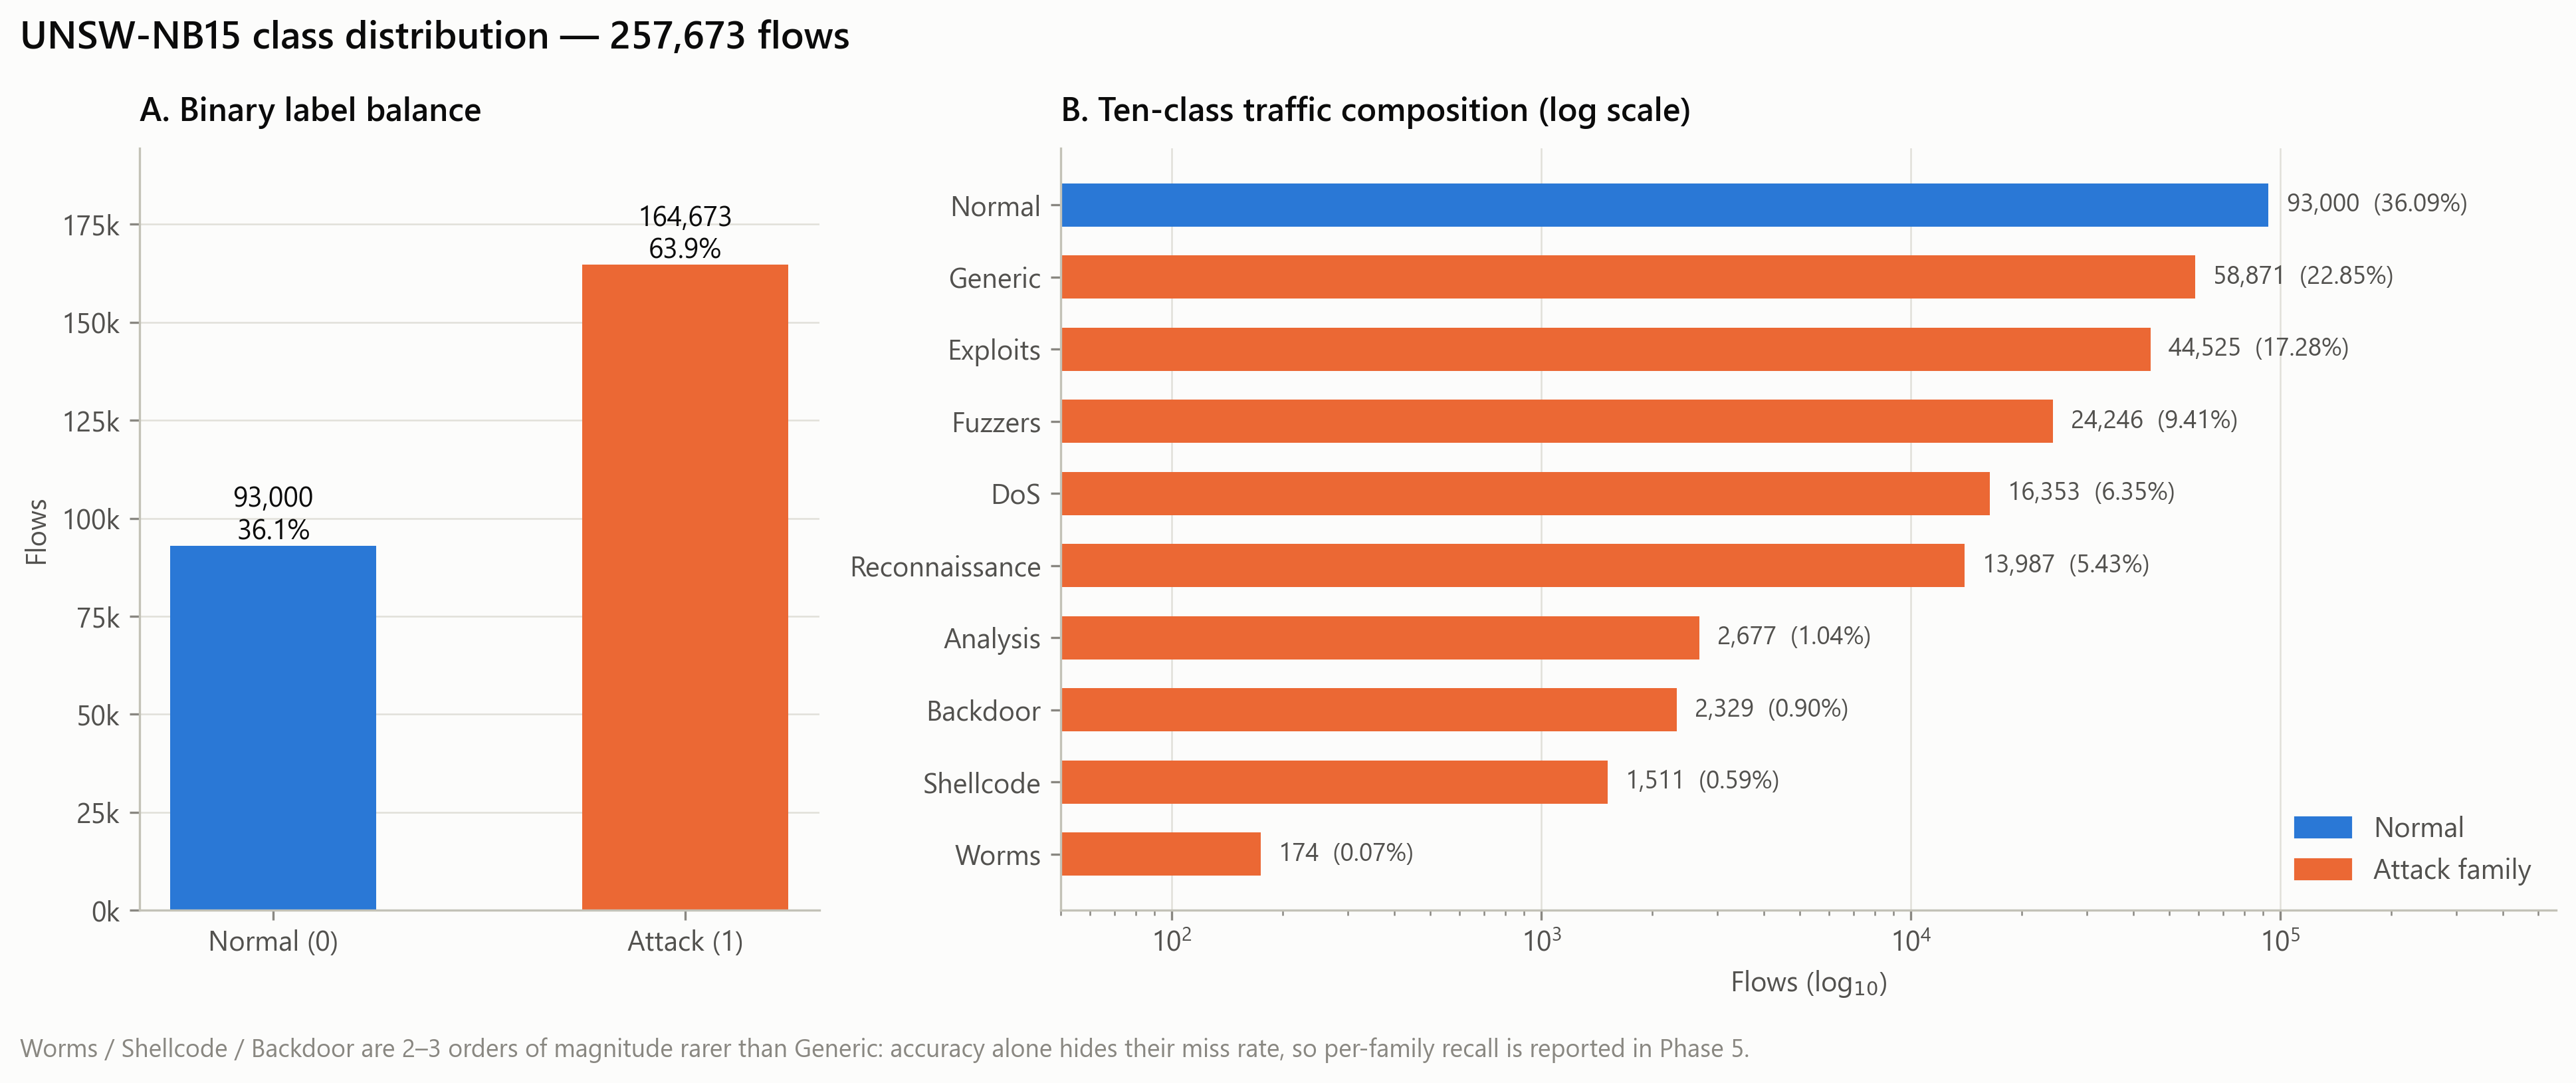

In [3]:
display(Image(filename=eda.fig_attack_distribution(df), width=1000))

**Insight → decision.** Attacks are 63.9 % of flows, but the families span three orders of magnitude
(Generic 58,871 vs Worms 174). Accuracy alone would hide a total failure on Worms, so Section 10 reports recall
per family, and class weighting (`balanced_subsample`) is used instead of SMOTE — interpolating between flow
records fabricates physically impossible packets.

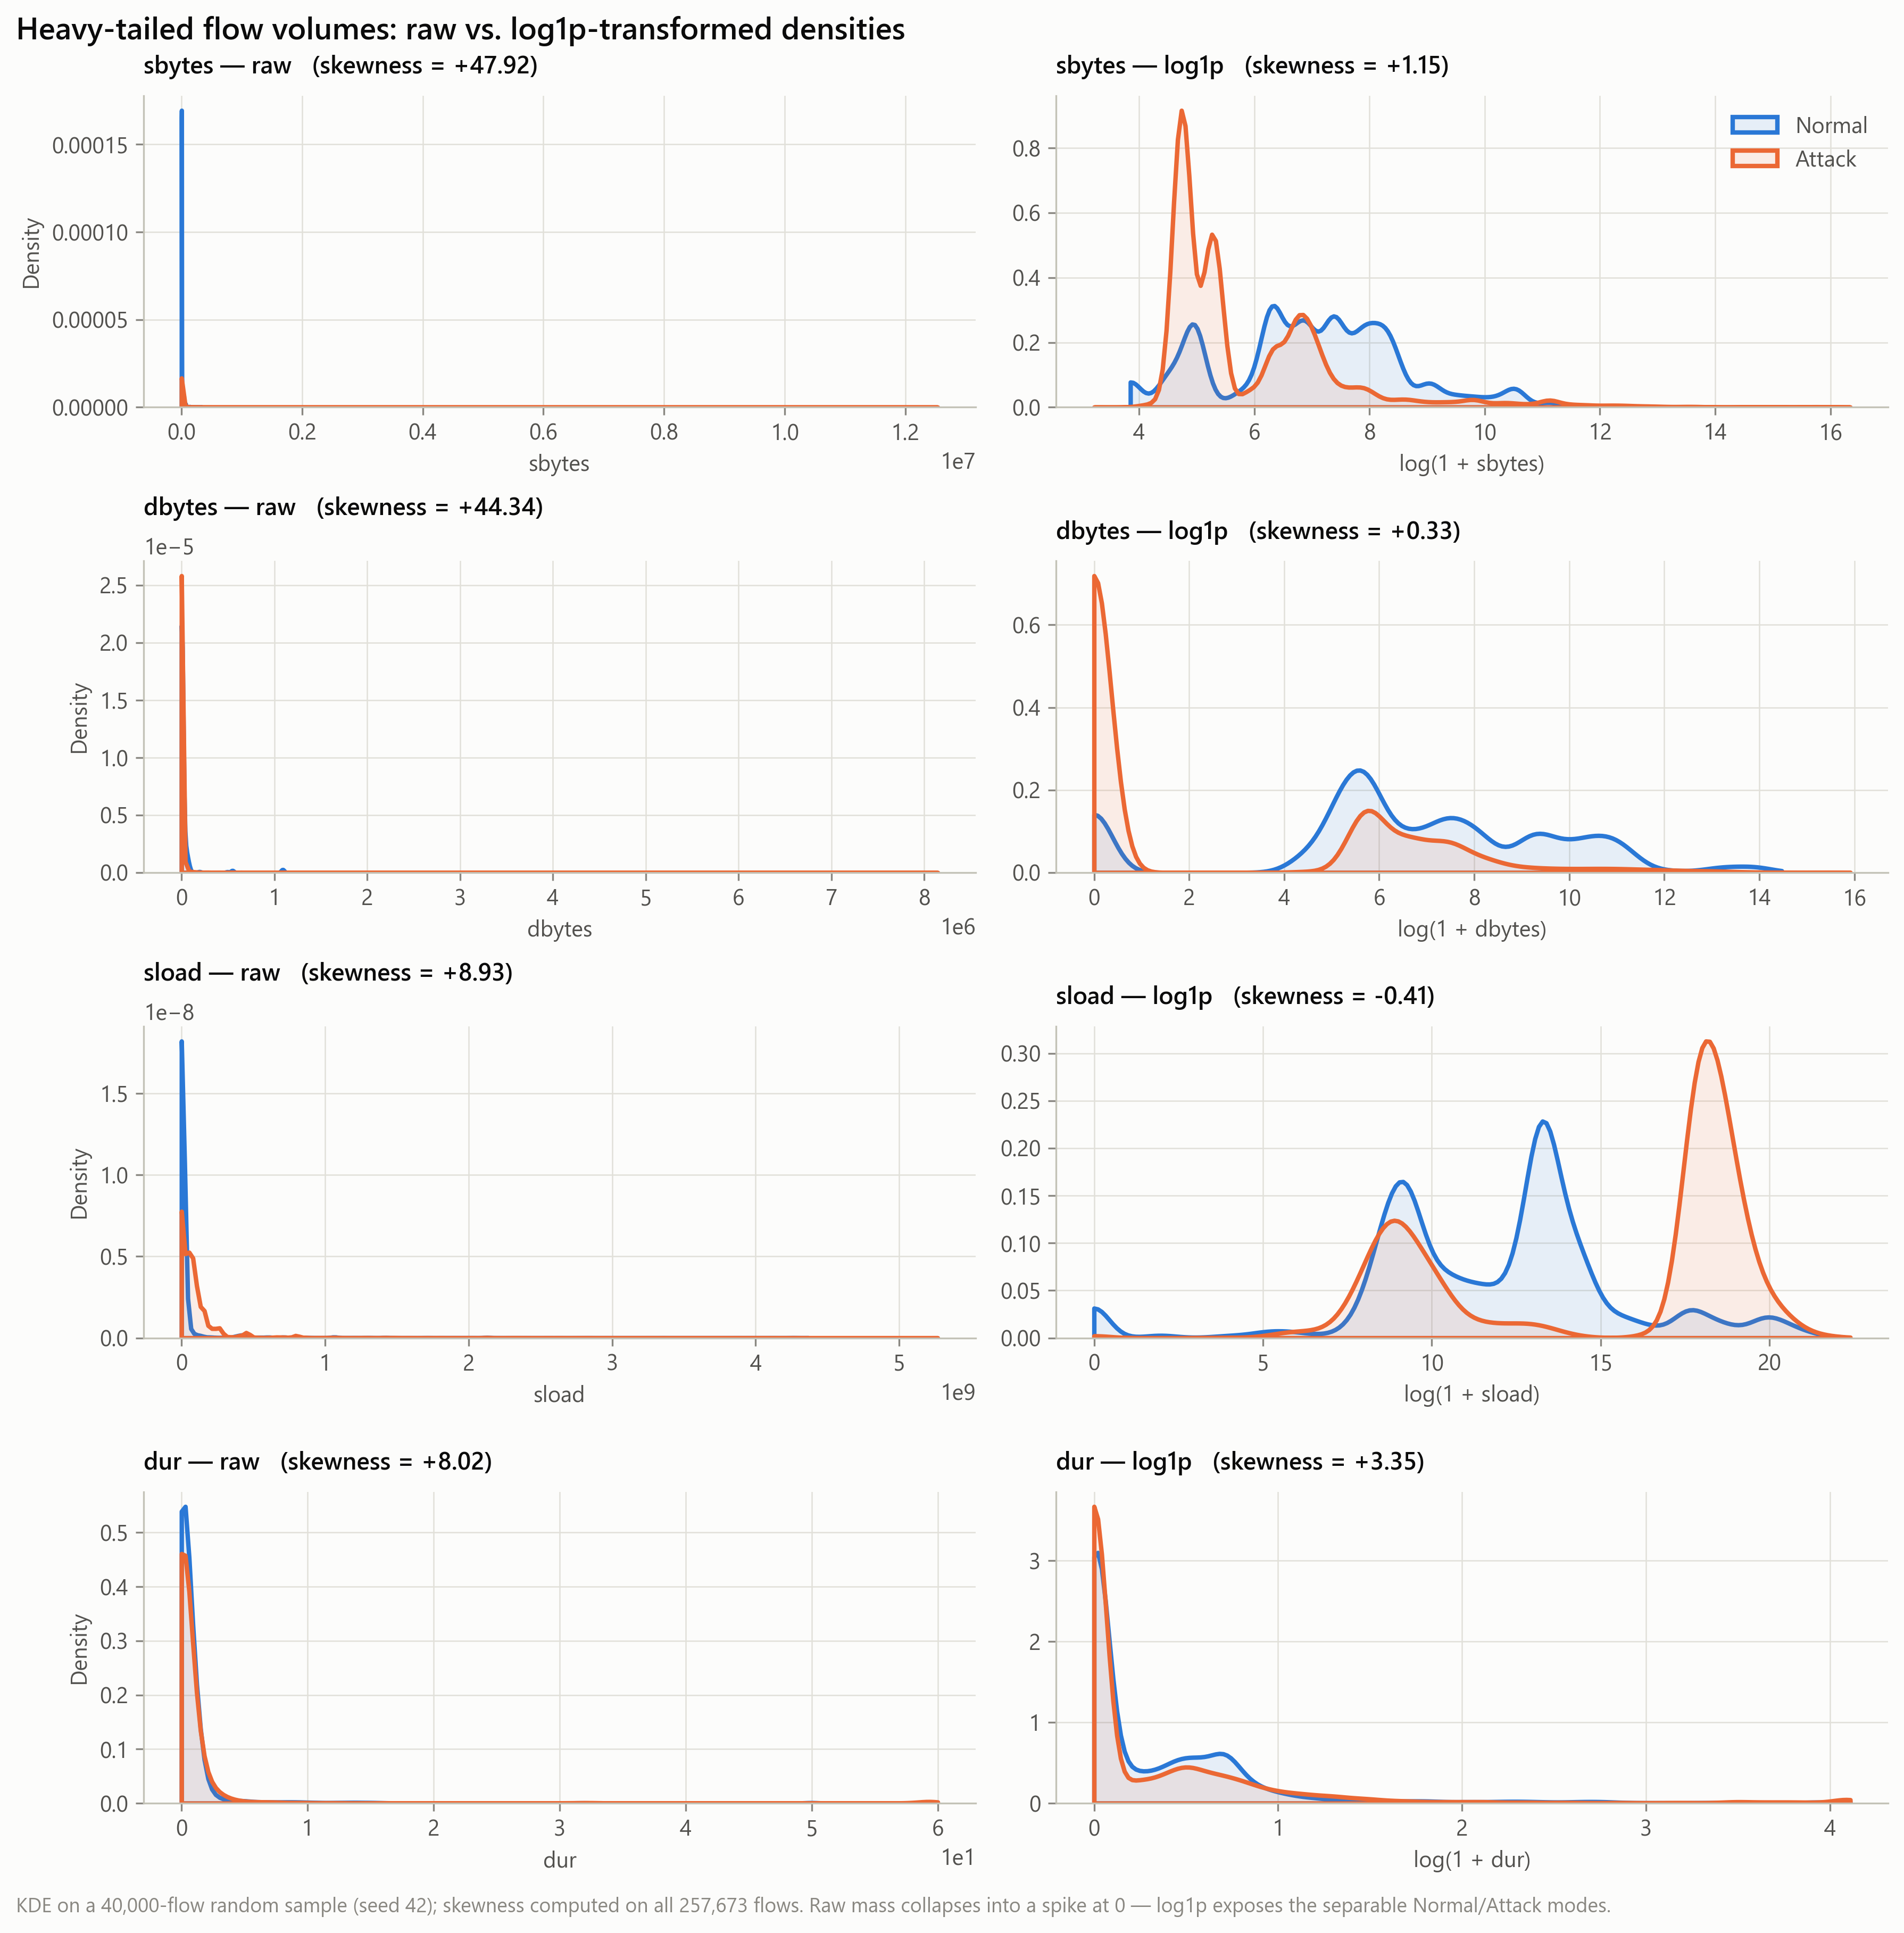

,raw skewness,log1p skewness,orders of magnitude
sbytes,47.9200,1.1500,5.8000
dbytes,44.3400,0.3300,5.7000
sload,8.9300,-0.4100,10.0000
dur,8.0200,3.3500,7.8000


In [4]:
display(Image(filename=eda.fig_volume_skew(df, rep), width=1000))
pd.DataFrame({"raw skewness": rep["skewness_raw"], "log1p skewness": rep["skewness_log1p"],
              "orders of magnitude": rep["orders_of_magnitude"]})

**Insight → decision.** Volume features are extremely heavy-tailed (sbytes skew ≈ 48, sload spans 10 orders
of magnitude). In raw space all mass collapses into a spike at zero; after `log1p` the Normal and Attack modes
separate. Hence `log1p` on the 9 volume/timing features followed by `RobustScaler` (median/IQR, immune to DDoS
spikes).

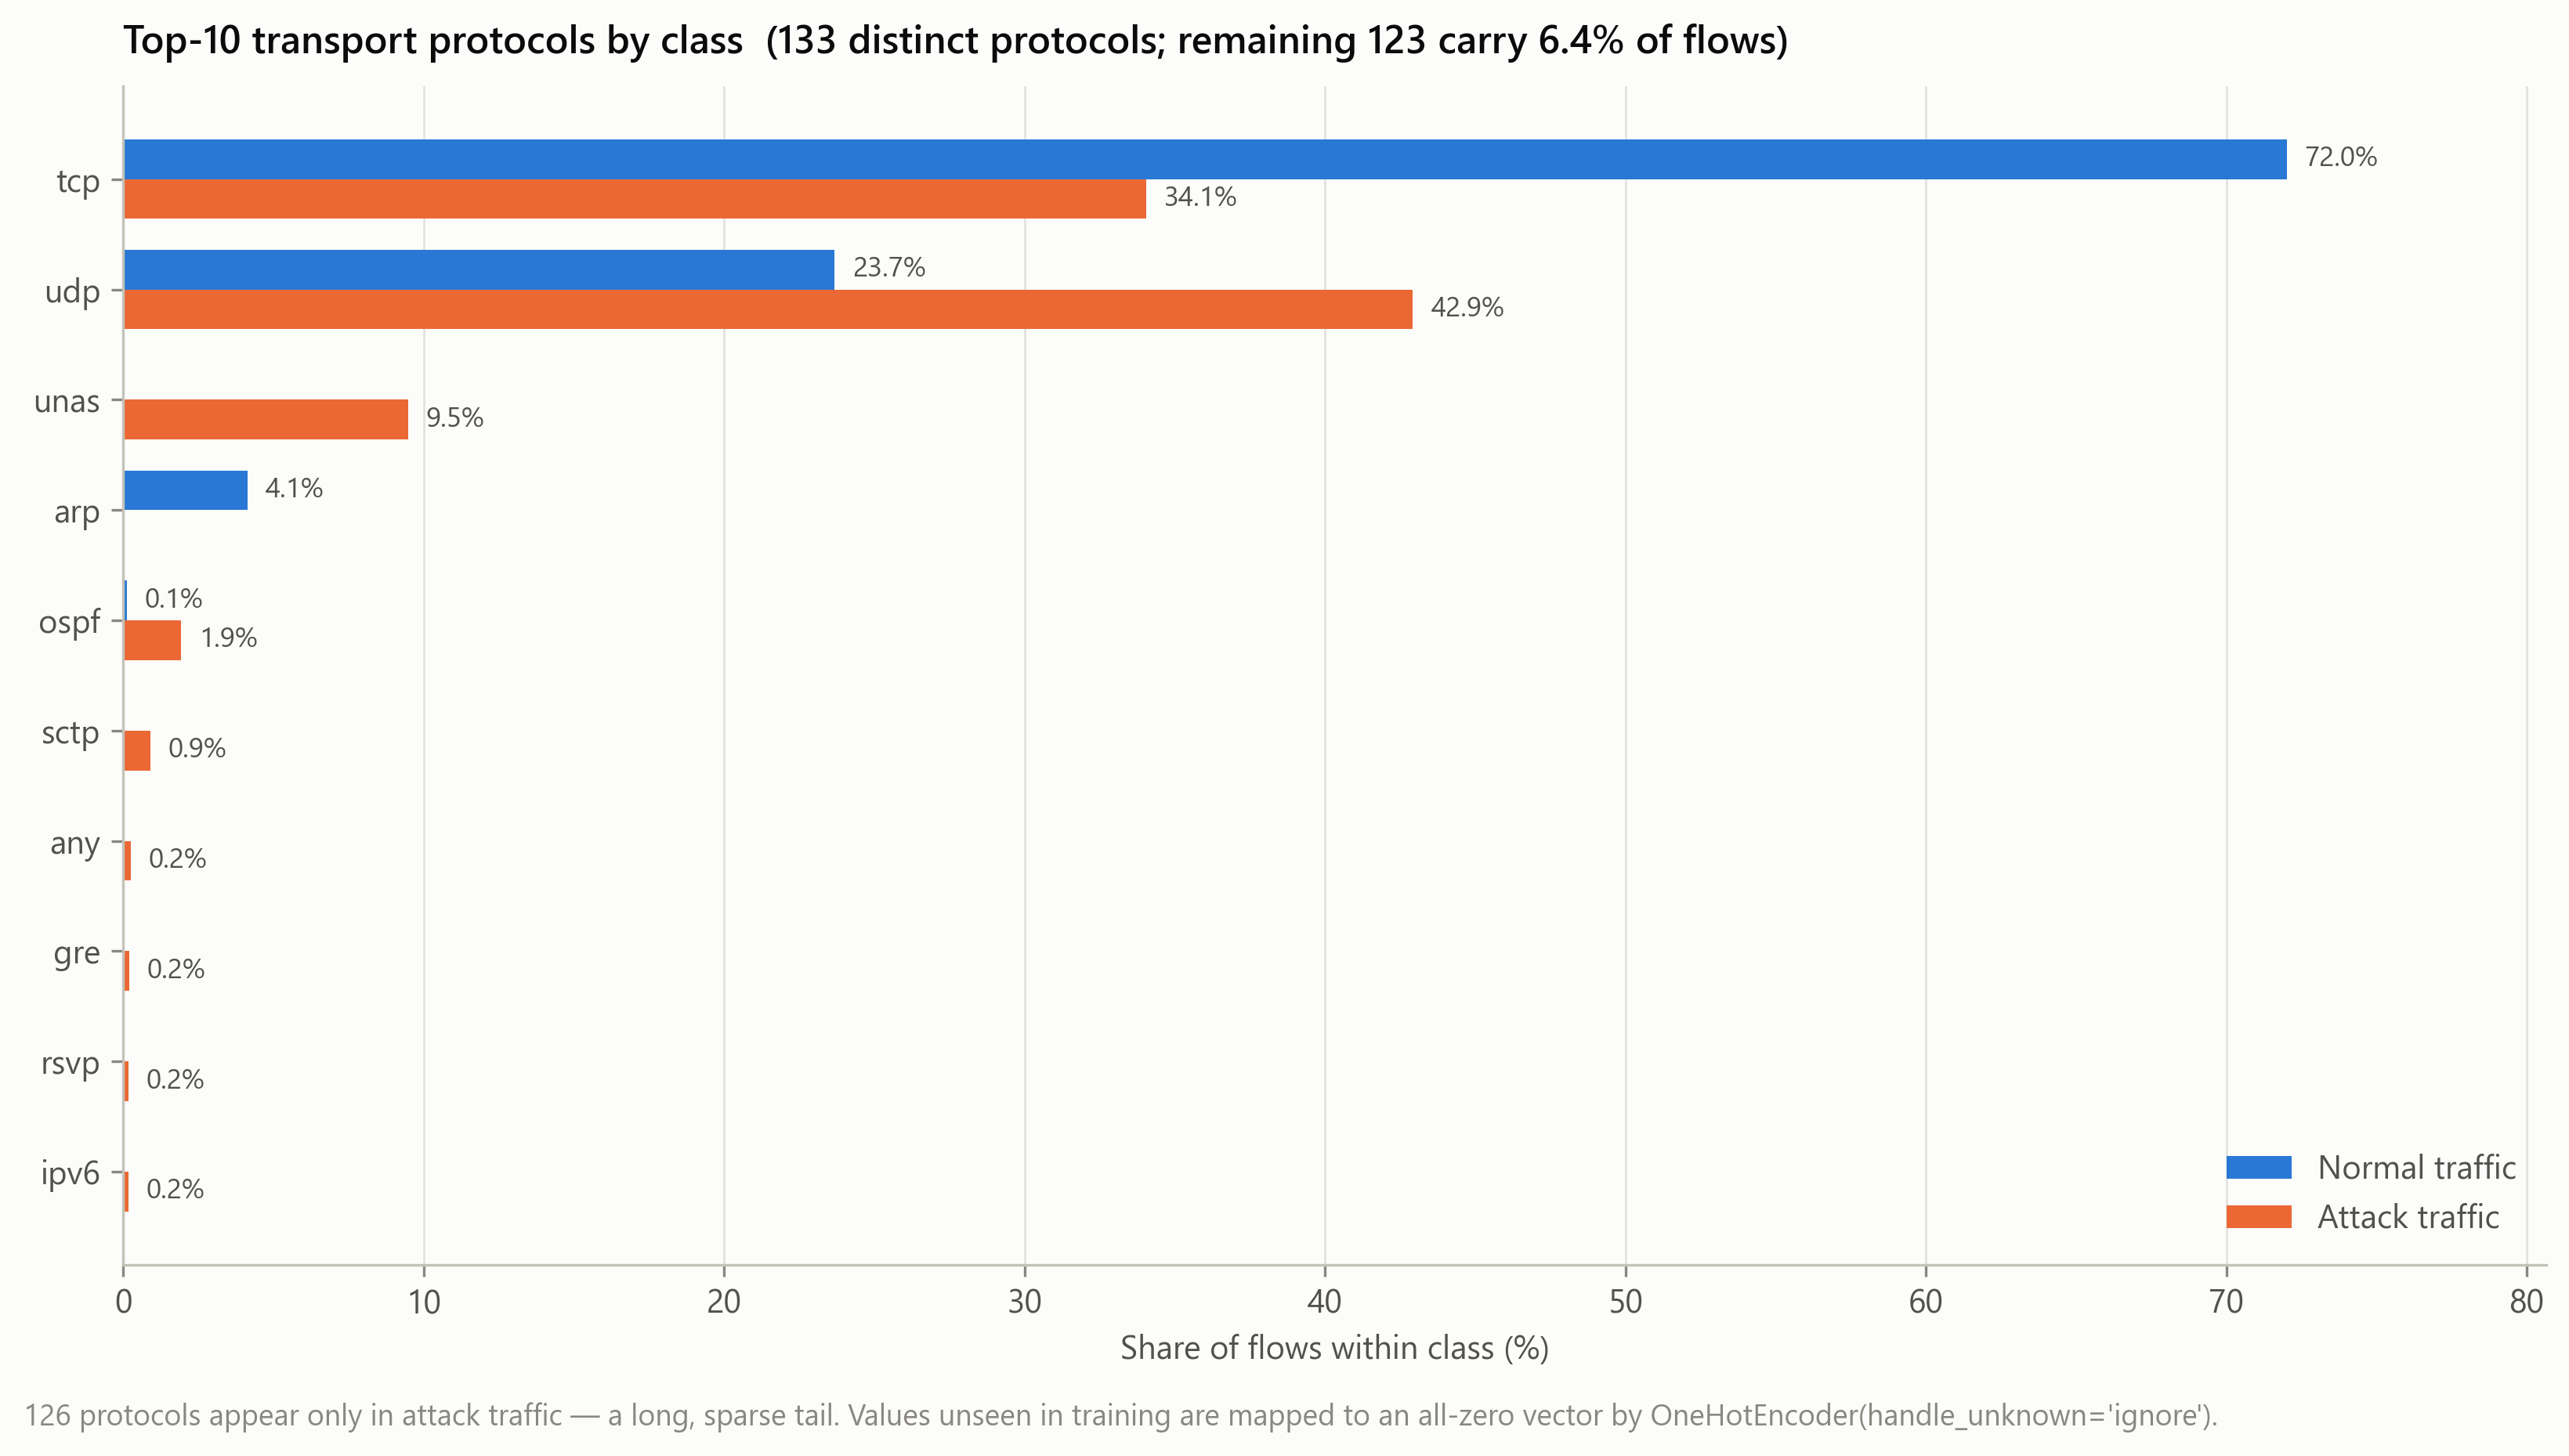

In [5]:
display(Image(filename=eda.fig_top_protocols(df), width=1000))

**Insight → decision.** 133 protocols, but 126 of them occur *only* in attack traffic and the tail beyond the
top-10 holds just 6.4 % of flows. Rare values can be absent from the training fold, so the encoder must not crash
on them: `OneHotEncoder(handle_unknown='ignore')`.

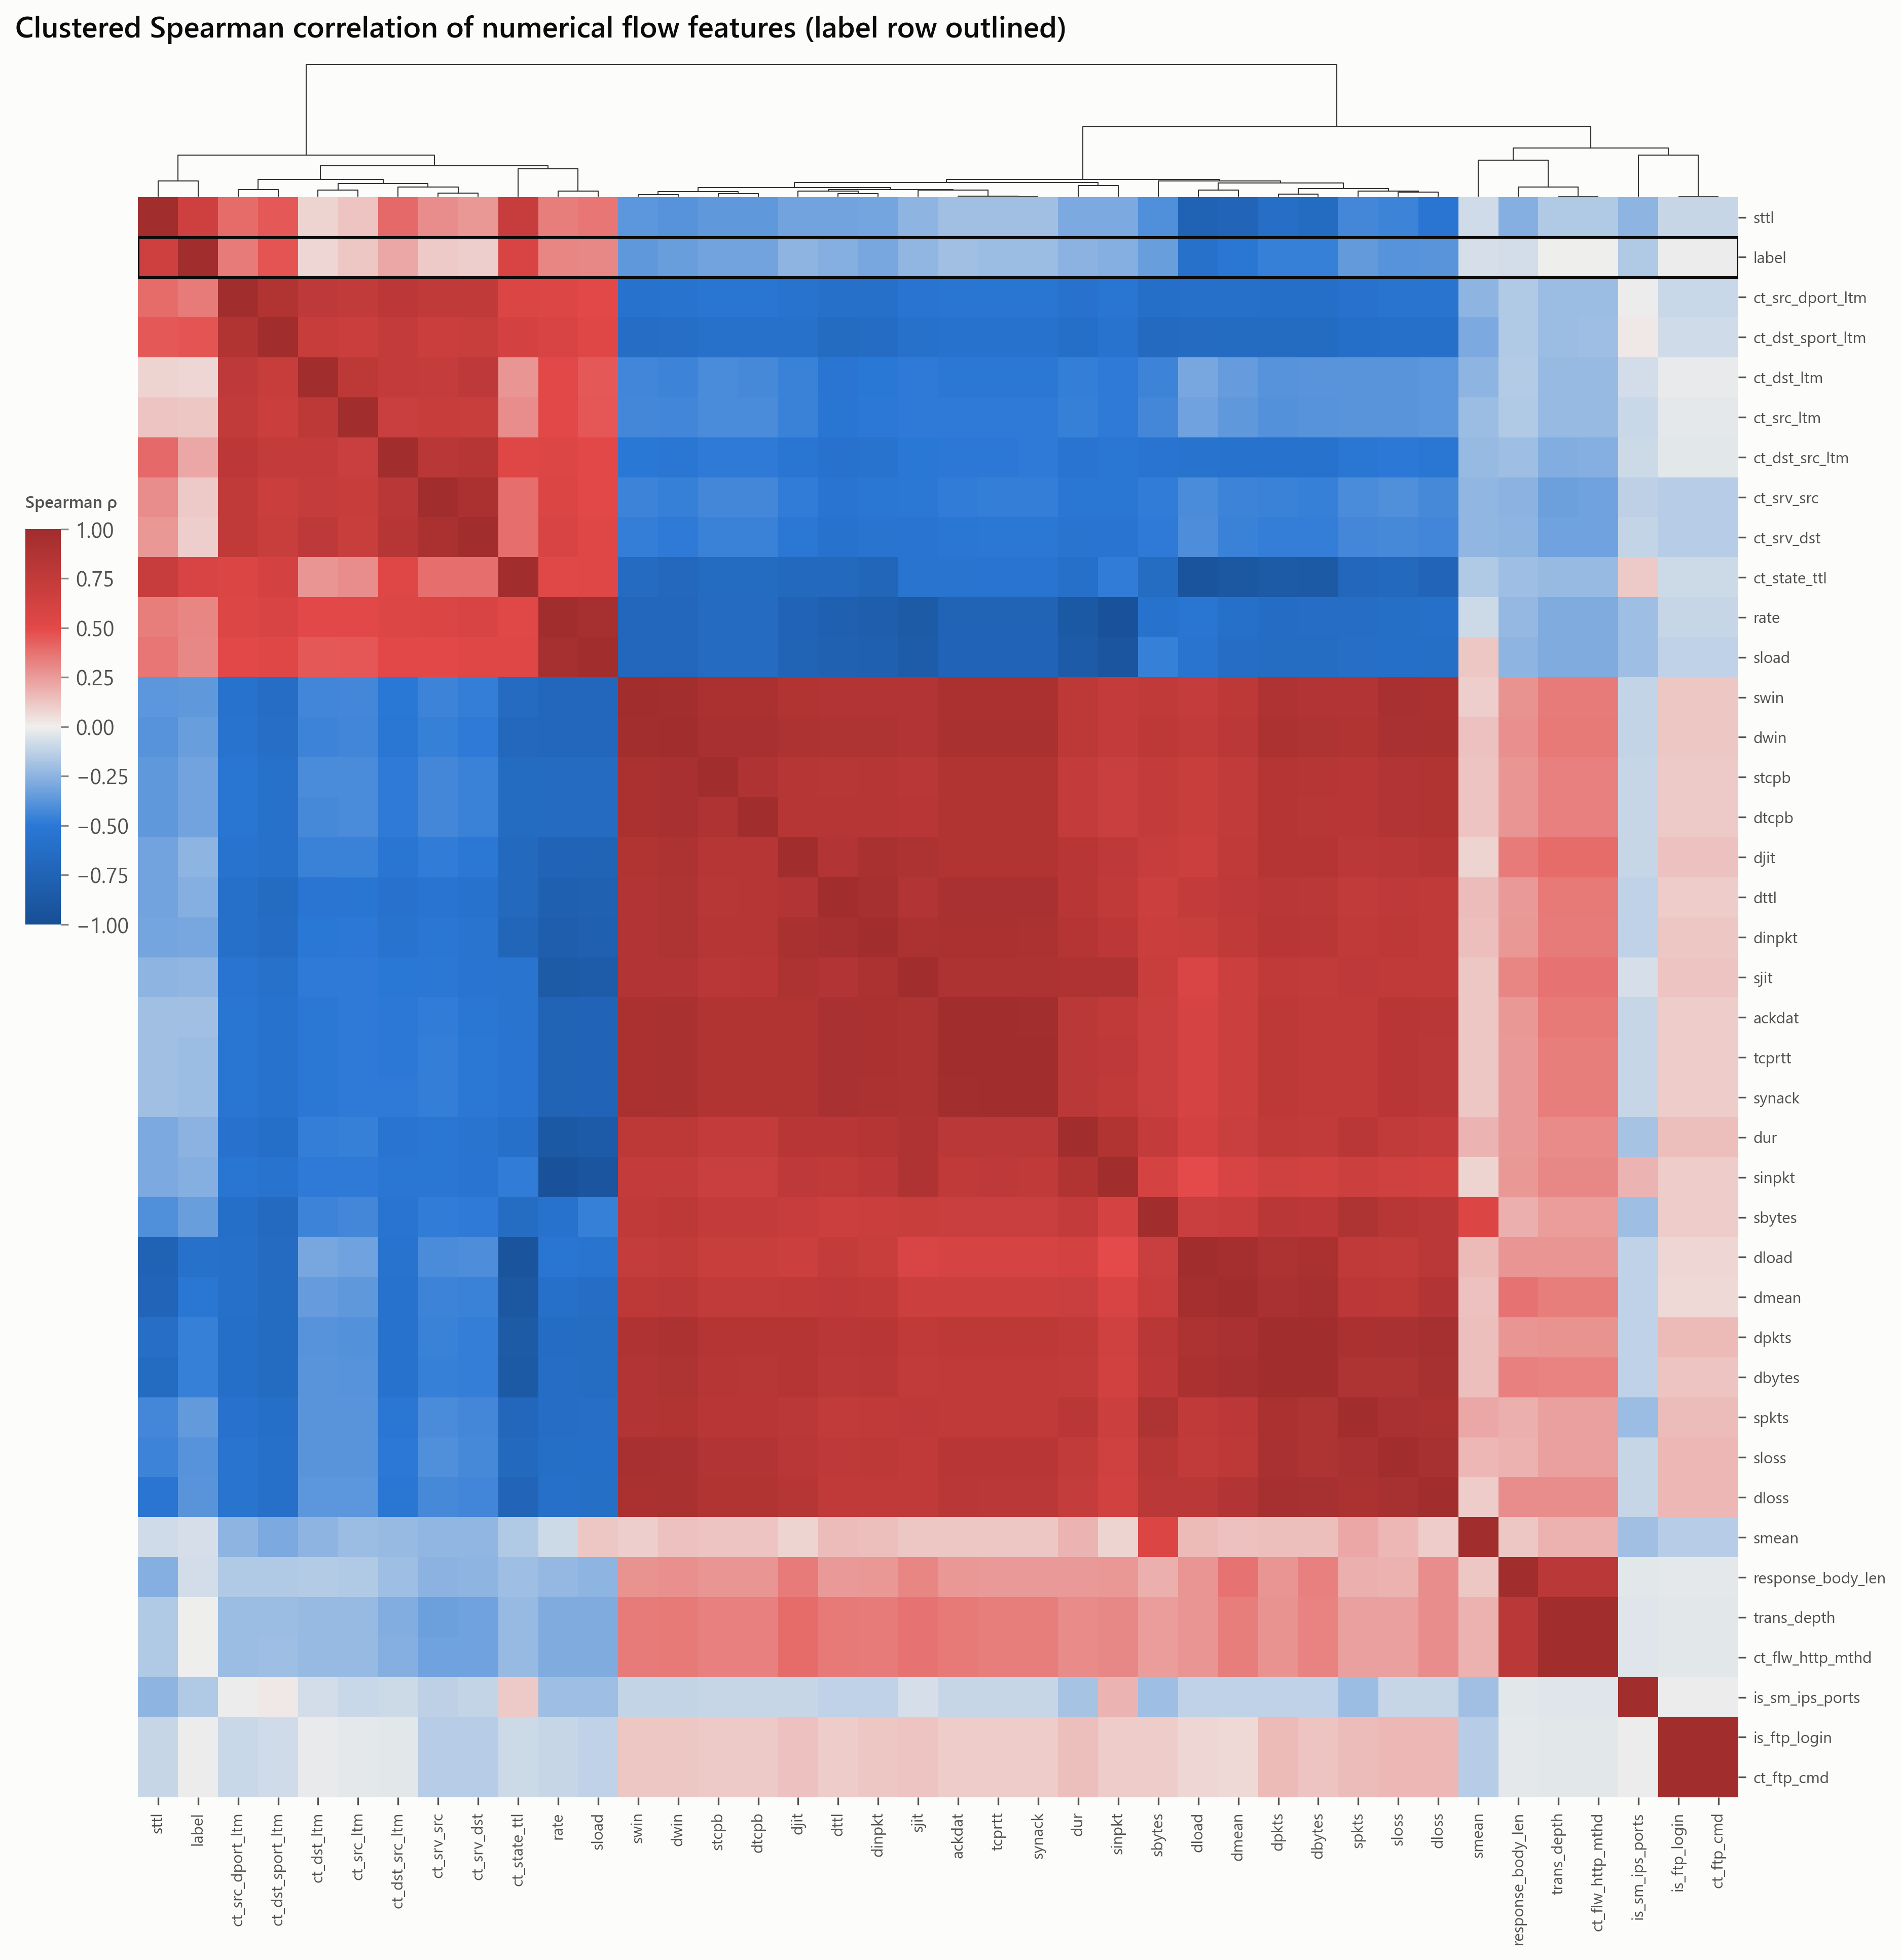

Most collinear pairs (|Spearman rho|):
is_ftp_login  ct_ftp_cmd         1.0000
trans_depth   ct_flw_http_mthd   1.0000
tcprtt        synack             0.9960
              ackdat             0.9930
dpkts         dbytes             0.9890
synack        ackdat             0.9820
swin          dwin               0.9810
dload         dmean              0.9630
dbytes        dmean              0.9610
rate          sload              0.9600


In [6]:
corr_path, top_pairs, label_corr = eda.fig_correlation(df)
display(Image(filename=corr_path, width=900))
print("Most collinear pairs (|Spearman rho|):"); print(top_pairs.to_string())

**Insight → decision.** Several features are near-duplicates (`is_ftp_login`~`ct_ftp_cmd` ρ = 1.0,
`tcprtt`~`synack` 0.996). Tree ensembles are insensitive to collinearity, which — together with non-linearity and
explainable Gini importances — motivates the Random Forest.

## 5. Preprocessing Pipeline & Stratified Split
The split happens **before** any statistic is learned. The `ColumnTransformer` is fitted on the 80 % training fold
only and merely *applied* to the frozen 20 % test fold.

In [7]:
d = pipeline.prepare_data()
Xp_tr, Xp_te, y_tr, y_te = d["Xp_tr"], d["Xp_te"], d["y_tr"], d["y_te"]
print(f"train {Xp_tr.shape}  test {Xp_te.shape}  NaN: {np.isnan(Xp_tr).sum() + np.isnan(Xp_te).sum()}")
print(f"attack rate  train {y_tr.mean():.4f}  test {y_te.mean():.4f}")
print("categorical values in test never seen in training:", pipeline.unseen_categories(d["pre"], d["X_te"]))
assert Xp_tr.shape[0] == 206_138 and Xp_te.shape[0] == 51_535
pd.concat([d["cat_tr"].value_counts().rename("train"), d["cat_te"].value_counts().rename("test")], axis=1)

train (206138, 195)  test (51535, 195)  NaN: 0
attack rate  train 0.6391  test 0.6391
categorical values in test never seen in training: {'proto': [], 'service': [], 'state': ['PAR']}


,train,test
attack_cat,,
Normal,74400,18600
Generic,47097,11774
Exploits,35620,8905
Fuzzers,19397,4849
DoS,13082,3271
Reconnaissance,11189,2798
Analysis,2142,535
Backdoor,1863,466
Shellcode,1209,302


## 6. Baseline Model — Decision Tree

In [8]:
t0 = time.perf_counter()
dt = DecisionTreeClassifier(random_state=SEED, max_depth=10, class_weight="balanced").fit(Xp_tr, y_tr)
p_dt = dt.predict_proba(Xp_te)[:, 1]
m_dt = binary_metrics(y_te, (p_dt >= 0.5).astype(int), p_dt)
print(f"trained in {time.perf_counter() - t0:.2f}s  |  {fmt(m_dt)}")

trained in 4.63s  |  acc=0.9292  prec=0.9829  recall=0.9050  f1=0.9423  fpr=0.0280  (TP=29,805 FP=520 FN=3,130 TN=18,080)


The single tree is precise but conservative: it misses **3,130** attacks (9.5% of all
attacks). That false-negative mass is the security gap an ensemble must close.

## 7. Champion Model — Tuned Random Forest
**Hyper-parameter search.** `GridSearchCV` (24 configurations × 3 stratified folds, scoring F1) was run by
`python -m src.champion` on a 30 % stratified subsample of the training fold (138 s). The results are loaded
here to keep the notebook under three minutes; the winning configuration is then refitted on the full training
fold.

In [9]:
cv = pd.read_csv(ARTIFACT_DIR / "rf_cv_results.csv")
display(cv.head(8))
best = json.loads((ARTIFACT_DIR / "metrics_champion.json").read_text())["tuning"]["best_params"]
best = {k: (None if v is None else int(v)) for k, v in best.items()}
print("best params:", best)

,param_n_estimators,param_max_depth,param_min_samples_split,param_min_samples_leaf,mean_test_f1,std_test_f1,mean_test_recall,mean_test_accuracy,rank_test_f1
0,150,NaN,5,2,0.9529,0.0016,0.9443,0.9403,1
1,200,NaN,5,2,0.9529,0.0017,0.9444,0.9403,2
2,200,30.0000,5,2,0.9527,0.0016,0.9436,0.9402,3
3,150,30.0000,5,2,0.9526,0.0017,0.9438,0.9400,4
4,150,25.0000,5,2,0.9521,0.0020,0.9422,0.9394,5
5,200,25.0000,5,2,0.9521,0.0021,0.9423,0.9394,6
6,150,NaN,10,2,0.9520,0.0017,0.9409,0.9394,7
7,150,25.0000,10,2,0.9520,0.0020,0.9396,0.9395,8


best params: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 150}


In [10]:
t0 = time.perf_counter()
rf = RandomForestClassifier(oob_score=True, n_jobs=-1, **best, **champion.RF_FIXED).fit(Xp_tr, y_tr)
print(f"champion fitted in {time.perf_counter() - t0:.1f}s  |  out-of-bag accuracy {rf.oob_score_:.4f}")

champion fitted in 16.7s  |  out-of-bag accuracy 0.9488


**Why the ≥ 95 % gate is not fully reachable (evidence, not excuse).** A separate experiment
(`experiments/model_selection_validation.py`, validation slice of the training fold only) tested an alternative
tree ensemble (ExtraTrees) and five engineered ratio features against the tuned forest. None lifts recall above
**≈ 94.3 % under FPR < 5 %** (ROC-AUC ≈ 0.99). Exact duplicate flows with conflicting labels explain only 0.26 % of error
(`experiments/irreducible_error_ceiling.py`); the remainder is genuine overlap between Normal traffic and
benign-looking attack flows — above all Fuzzers (Section 10). The project therefore keeps the RF champion
(DEC-003) and reports the shortfall transparently.

## 8. Decision Threshold Optimisation (τ*)
Probabilities come from the RF's **out-of-bag** estimates: every training flow is scored only by trees that never
saw it — a free, leak-free validation set. Rule (fixed before looking at the test fold): within τ ∈ [0.30, 0.70]
choose the τ with maximum attack recall subject to FPR < 5 %, ties broken by F1.

tau* = 0.50  (max-recall s.t. FPR<5%)


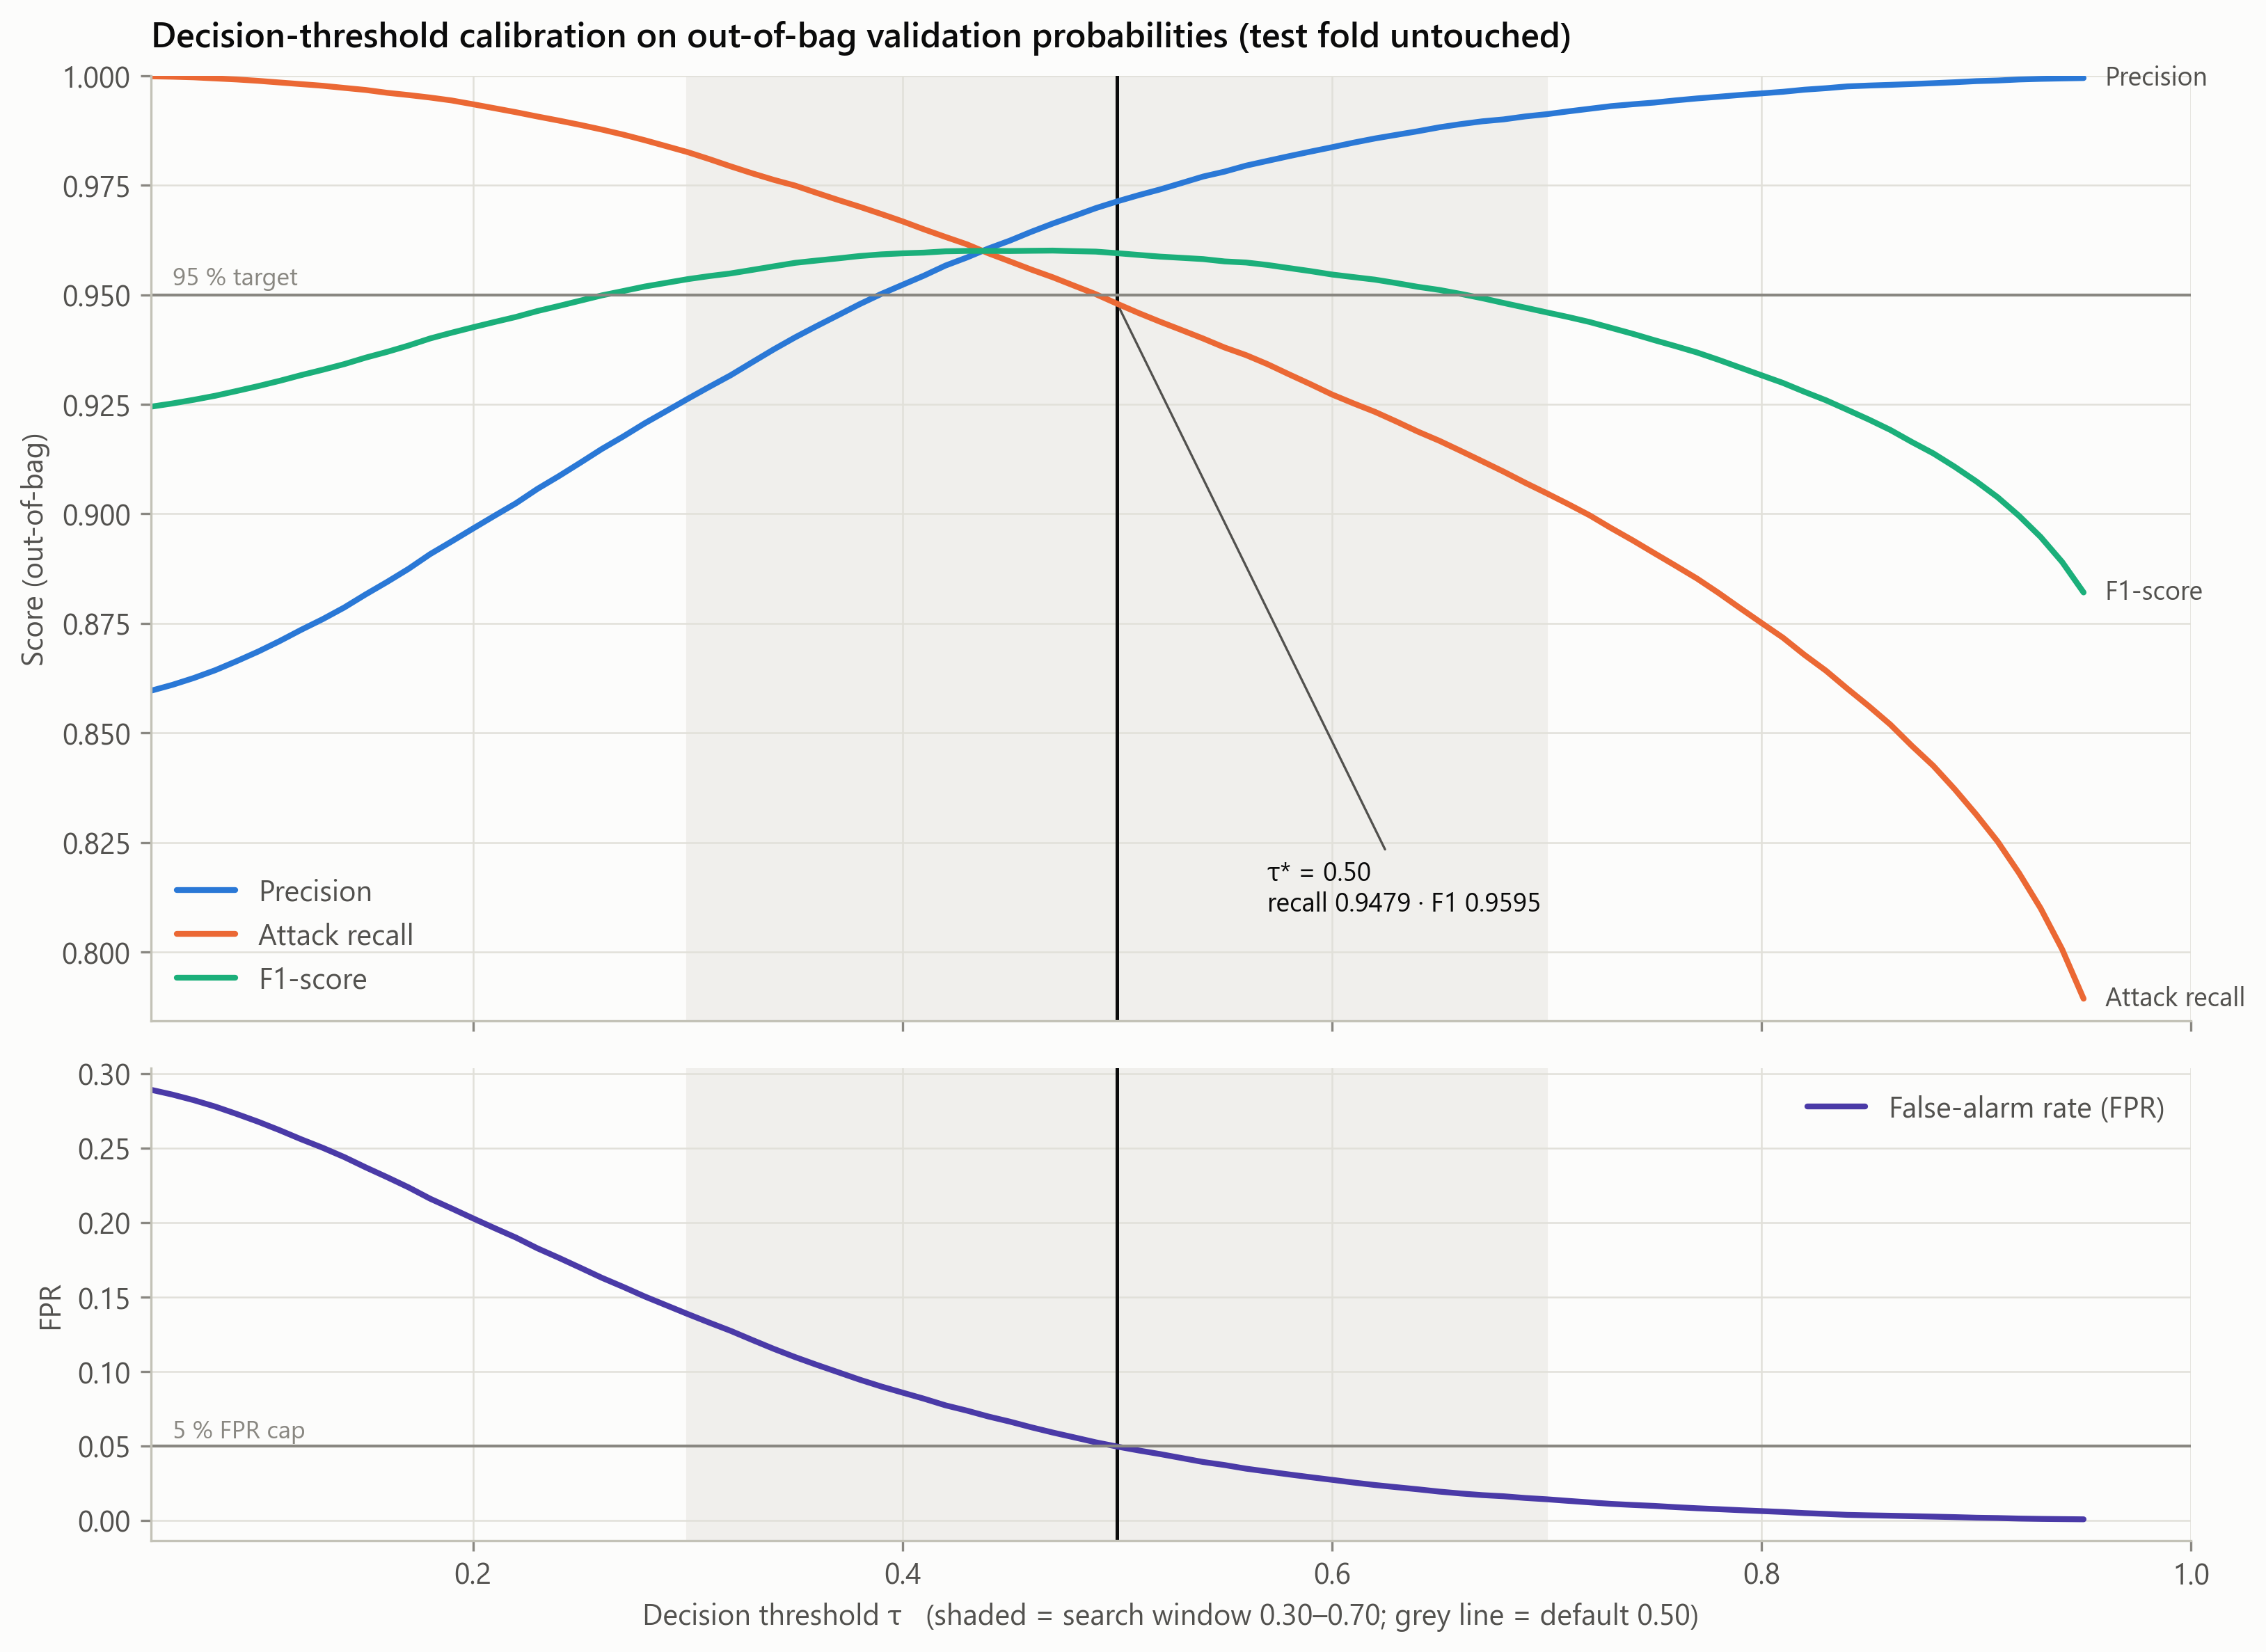

,accuracy,precision,recall,f1,fpr
tau,,,,,
0.4000,0.9478,0.9523,0.9668,0.9595,0.0858
0.4100,0.9481,0.9544,0.9649,0.9596,0.0817
0.4200,0.9486,0.9567,0.9632,0.9599,0.0773
0.4300,0.9488,0.9585,0.9615,0.9600,0.0737
0.4400,0.9489,0.9606,0.9595,0.9600,0.0698
0.4500,0.9490,0.9624,0.9576,0.9600,0.0663
0.4600,0.9491,0.9644,0.9557,0.9600,0.0625
0.4700,0.9493,0.9662,0.9540,0.9601,0.0590
0.4800,0.9492,0.9680,0.9520,0.9600,0.0558


In [11]:
oob = rf.oob_decision_function_[:, 1]; ok = ~np.isnan(oob)
sw = champion.sweep(y_tr.to_numpy()[ok], oob[ok])
tau, rule = champion.select_tau(sw)
print(f"tau* = {tau:.2f}  ({rule})")
display(Image(filename=champion.fig_threshold(sw, tau), width=950))
sw[(sw.tau >= 0.40) & (sw.tau <= 0.60)].set_index("tau")

Lowering τ below 0.50 would buy recall, but OOB FPR crosses the 5 % false-alarm budget immediately — the
curve makes the trade-off explicit. The CISO can move τ along this curve as a *policy* knob.

## 9. Comparative Model Evaluation & Confusion Matrix (untouched test fold)

In [12]:
p_rf = rf.predict_proba(Xp_te)[:, 1]
m_rf = binary_metrics(y_te, (p_rf >= tau).astype(int), p_rf)
cols = ["accuracy", "precision", "recall", "f1", "fpr", "roc_auc", "tp", "fp", "fn", "tn"]
table = pd.DataFrame([m_dt, m_rf], index=["Decision Tree @0.50", f"Tuned RF @{tau:.2f} (champion)"])[cols]
display(table)
gates = {"accuracy>=95%": m_rf["accuracy"] >= .95, "recall>=95%": m_rf["recall"] >= .95,
         "F1>=95%": m_rf["f1"] >= .95, "FPR<5%": m_rf["fpr"] < .05}
print("Champion acceptance gates:", gates)

,accuracy,precision,recall,f1,fpr,roc_auc,tp,fp,fn,tn
Decision Tree @0.50,0.9292,0.9829,0.9050,0.9423,0.0280,0.9859,29805,520,3130,18080
Tuned RF @0.50 (champion),0.9471,0.9705,0.9460,0.9581,0.0509,0.9915,31155,947,1780,17653


Champion acceptance gates: {'accuracy>=95%': False, 'recall>=95%': False, 'F1>=95%': True, 'FPR<5%': False}


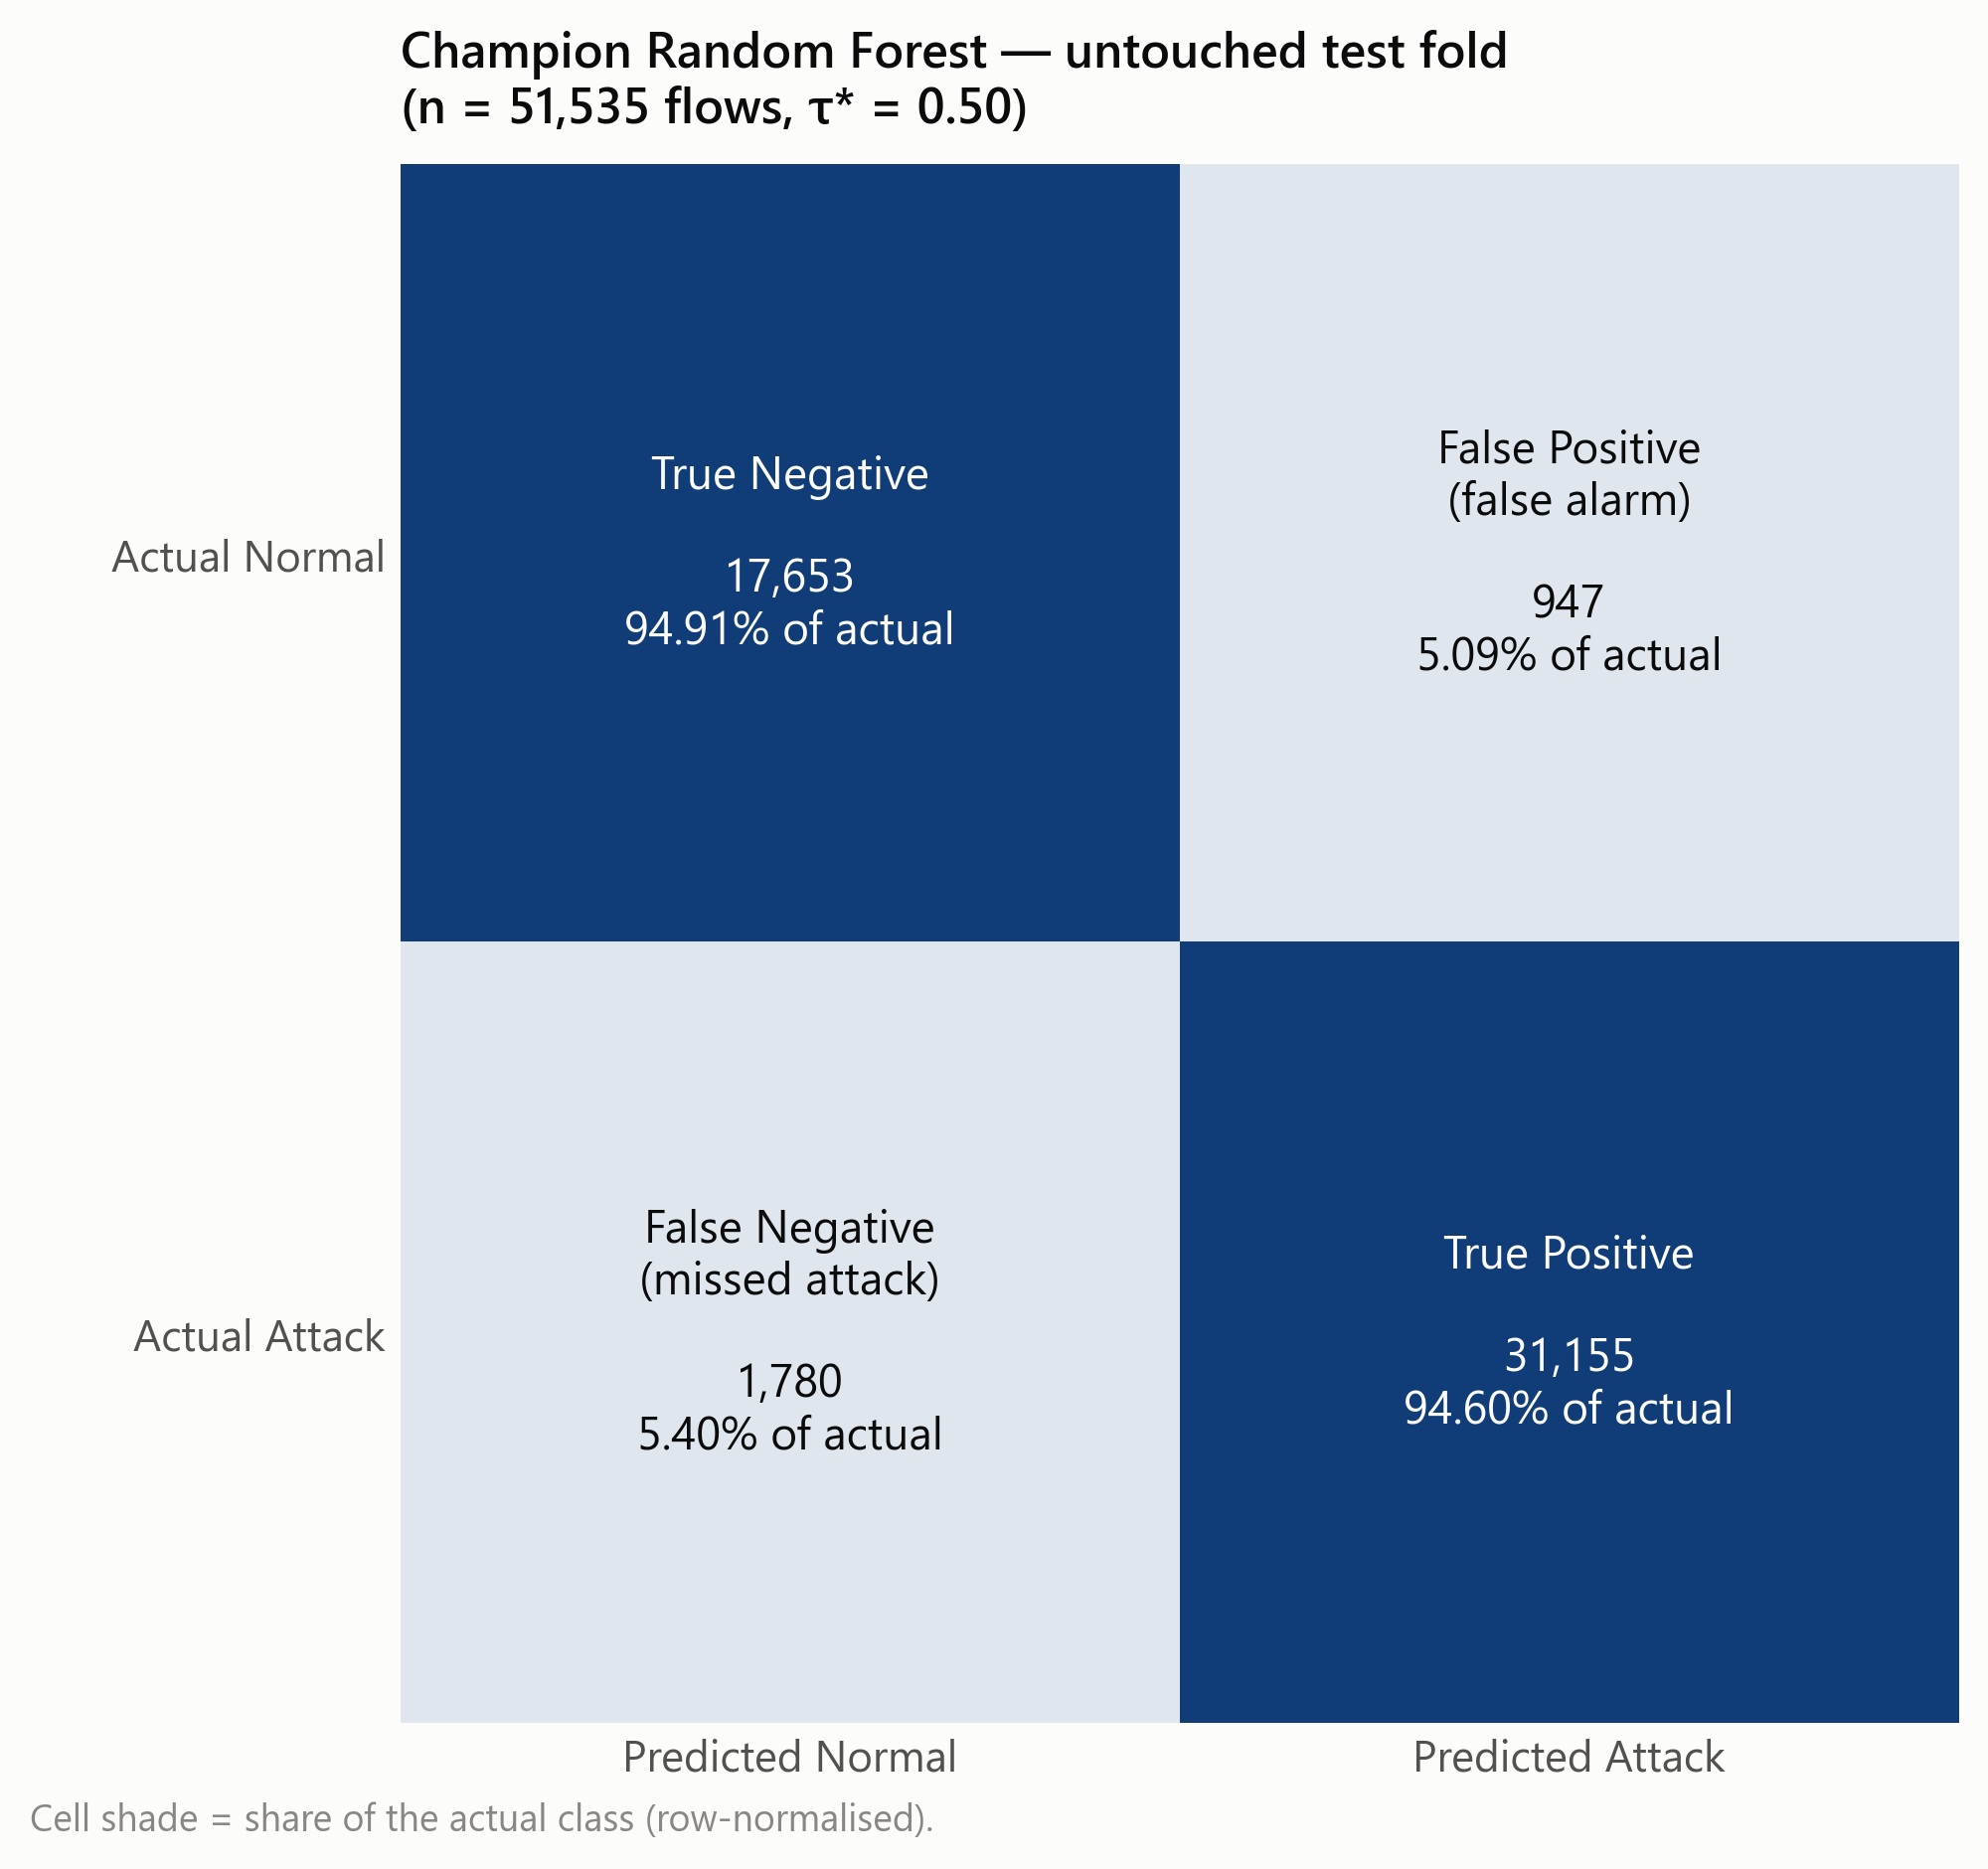

In [13]:
cm = np.array([[m_rf["tn"], m_rf["fp"]], [m_rf["fn"], m_rf["tp"]]])
display(Image(filename=security_eval.fig_confusion(cm, tau), width=620))

**Operational trade-off.** Per 10,000 flows the champion raises ≈ 184
false alarms (analyst triage time) and misses ≈ 345 attacks (breach risk).
A false positive costs minutes of SOC effort; a false negative can cost persistence, lateral movement and data
exfiltration — so recall is weighted above precision, within an explicit false-alarm budget.

## 10. Granular 9-Family Attack Recall & Security Critique

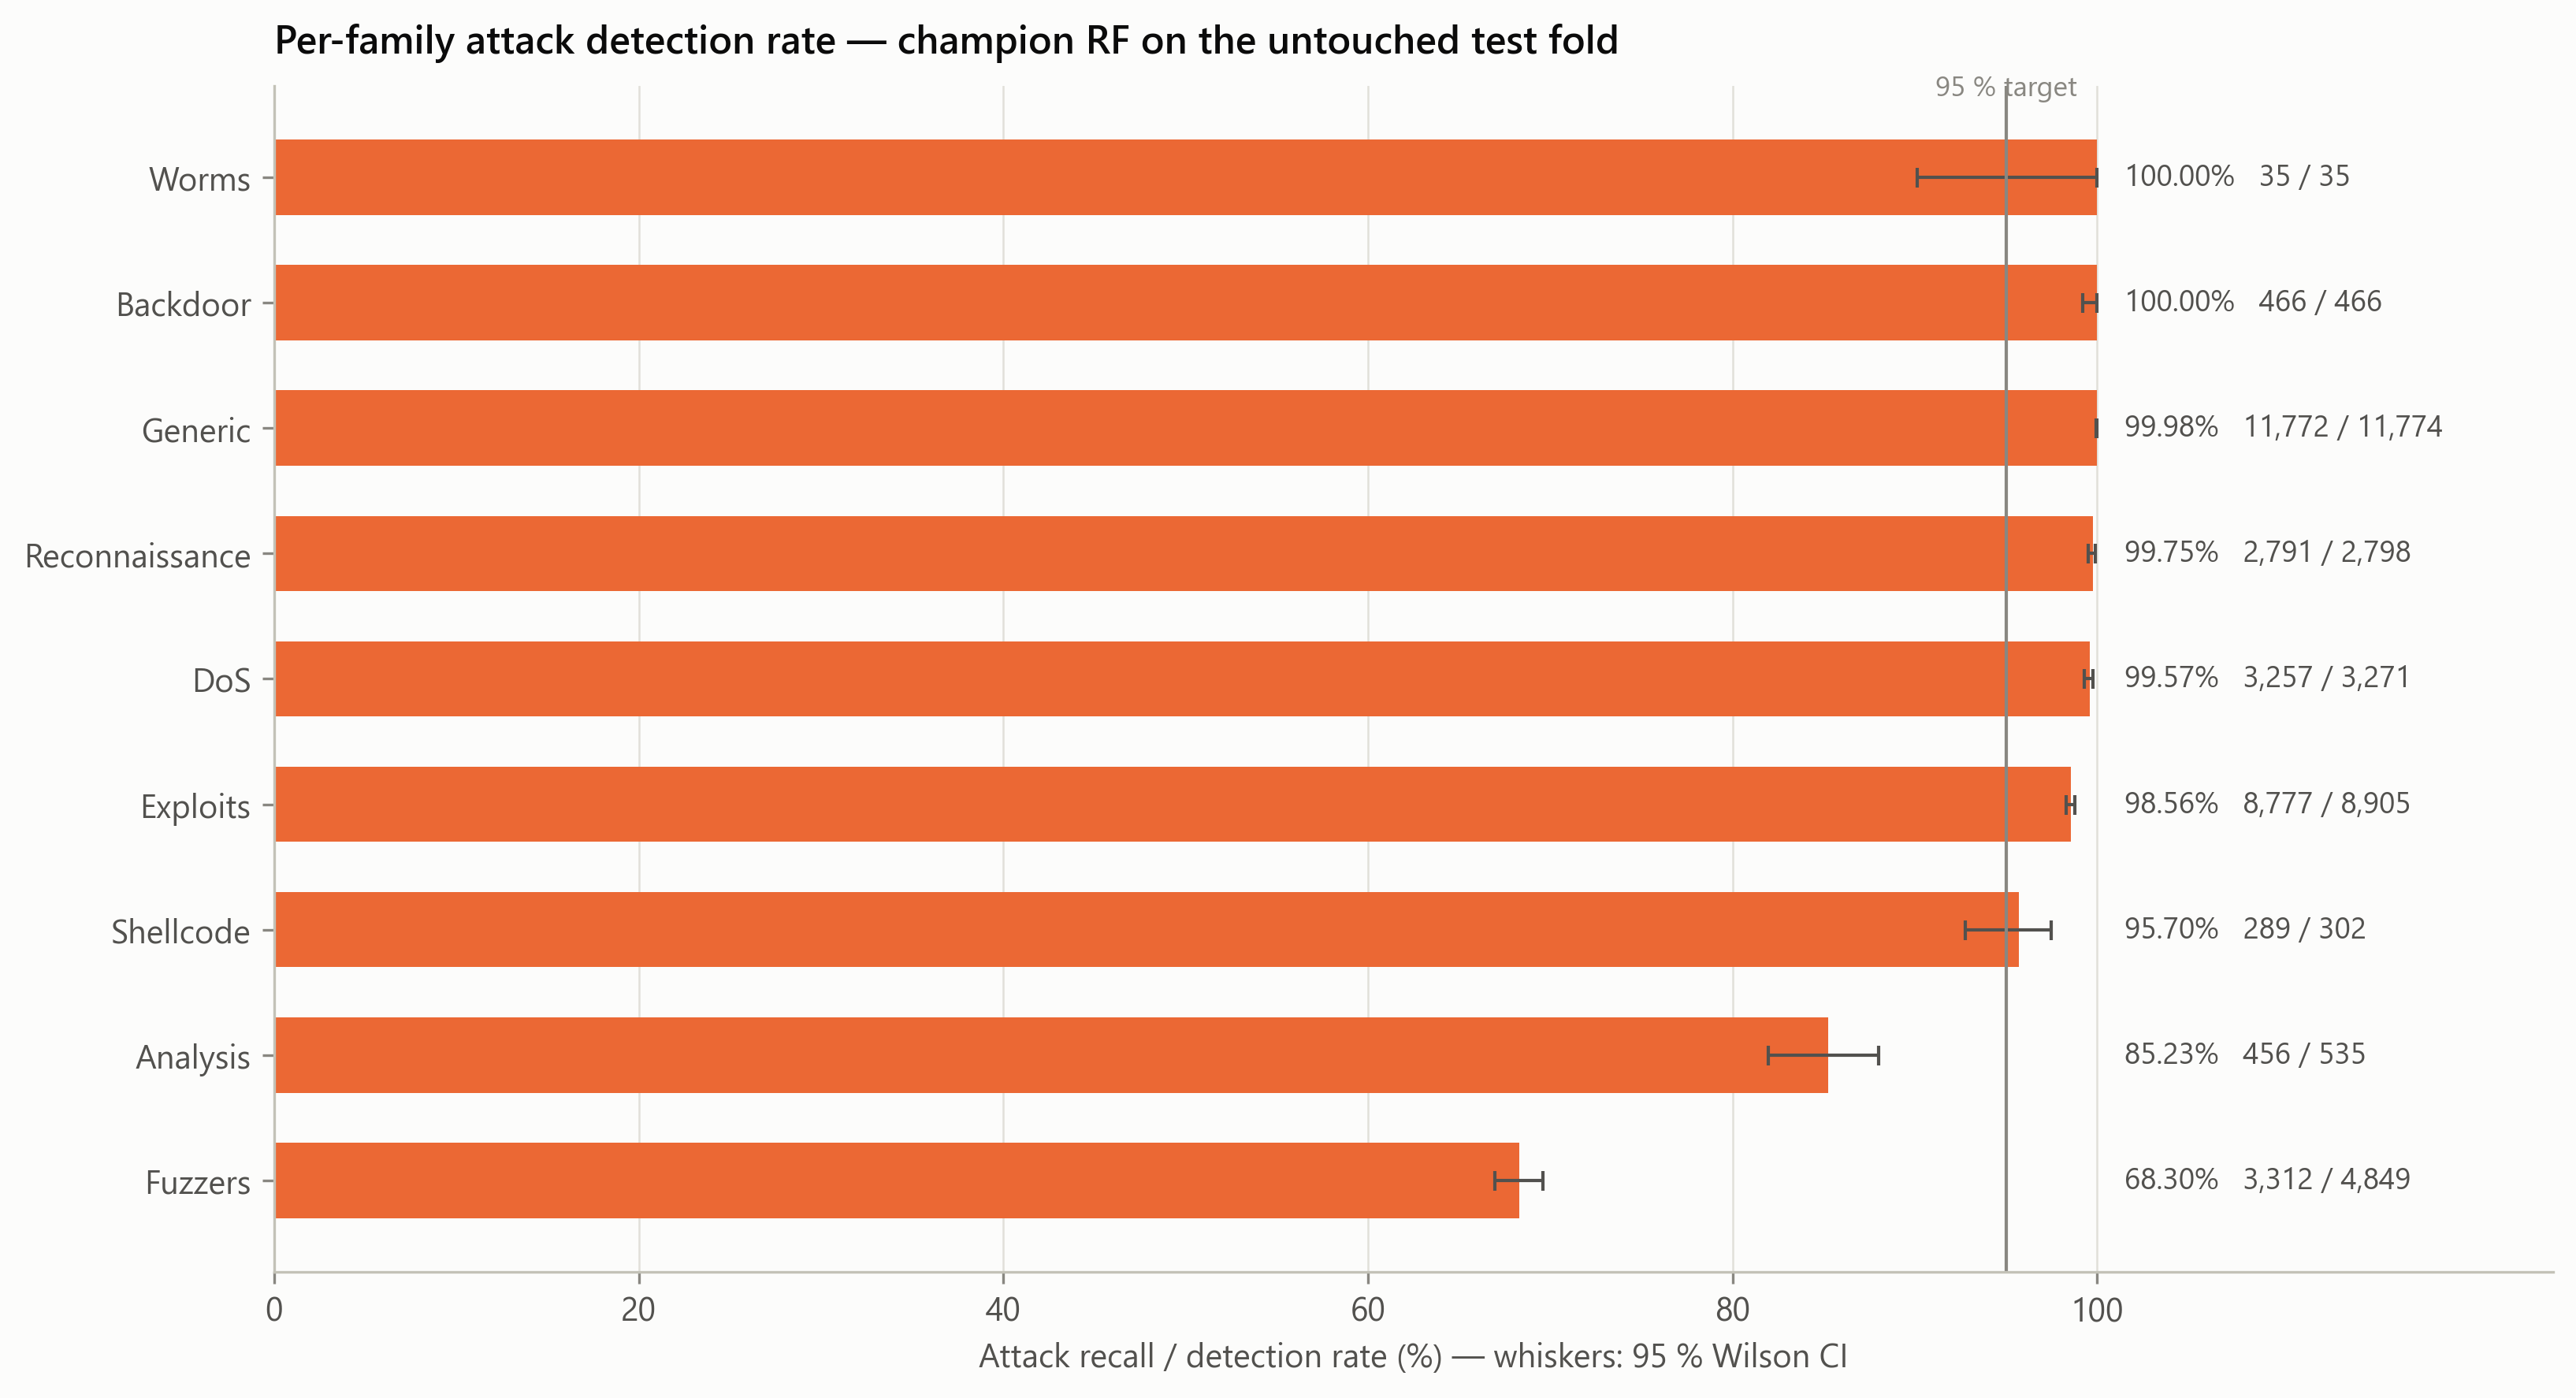

,family,support,detected,missed,recall,ci_lo,ci_hi,share_of_all_misses
2,Fuzzers,4849,3312,1537,0.6830,0.6698,0.6960,0.8635
5,Analysis,535,456,79,0.8523,0.8198,0.8799,0.0444
7,Shellcode,302,289,13,0.9570,0.9278,0.9747,0.0073
1,Exploits,8905,8777,128,0.9856,0.9829,0.9879,0.0719
3,DoS,3271,3257,14,0.9957,0.9928,0.9974,0.0079
4,Reconnaissance,2798,2791,7,0.9975,0.9948,0.9988,0.0039
0,Generic,11774,11772,2,0.9998,0.9994,1.0000,0.0011
6,Backdoor,466,466,0,1.0000,0.9918,1.0000,0.0000
8,Worms,35,35,0,1.0000,0.9011,1.0000,0.0000


In [14]:
pred = pd.DataFrame({"attack_cat": d["cat_te"], "rf_pred": (p_rf >= tau).astype(int), "rf_proba": p_rf})
t = security_eval.recall_table(pred)
assert t.support.sum() == int(y_te.sum()) and t.missed.sum() == m_rf["fn"]
display(Image(filename=security_eval.fig_recall(t), width=950))
t.sort_values("recall")[["family", "support", "detected", "missed", "recall", "ci_lo", "ci_hi", "share_of_all_misses"]]

**Critical security analysis.** Only 2 of 9 families fall below 95 %
recall: **Fuzzers** (68.3%), **Analysis** (85.2%).

* **Fuzzers are the dominant blind spot** — 1,537 missed flows, **86% of all
  false negatives**. Fuzzing floods a service with malformed or random input to find crashable code; at the flow
  level many fuzzing sessions are short, low-volume exchanges over ordinary services whose byte, TTL and timing
  statistics match benign clients. The ceiling analysis corroborates this: the *only* exact feature-vector
  collisions between classes in the dataset are Normal ↔ Fuzzers. **Security implication:** an adversary fuzzing an
  internet-facing service for a zero-day would largely go unnoticed, so detection shifts from the discovery phase
  to the far more damaging exploitation phase.
* **Analysis** (79 of 535 missed) covers port scans, spam and HTML-file penetration
  probes — missed flows mean vulnerability probing goes unlogged.
* **Rare ≠ undetected.** Contrary to the usual expectation, the rarest families — **Worms (100%) and
  Backdoor (100%)** — are fully detected: their TTL/state fingerprints are highly distinctive. Worms'
  Wilson interval still spans [90.1%, 100 %] because only 35 test flows exist, and a single
  missed worm would be disproportionately dangerous because it self-propagates.
* **Mitigation roadmap.** (i) payload-aware features (DPI, TLS/JA3 fingerprints) for Fuzzers and Analysis, which are
  indistinguishable at flow level; (ii) family-specific or cost-sensitive thresholds; (iii) correlate ML alerts with
  signature IDS and host EDR telemetry (defence in depth) rather than relying on a single detector.

## 11. Feature Importance & SOC Explainability

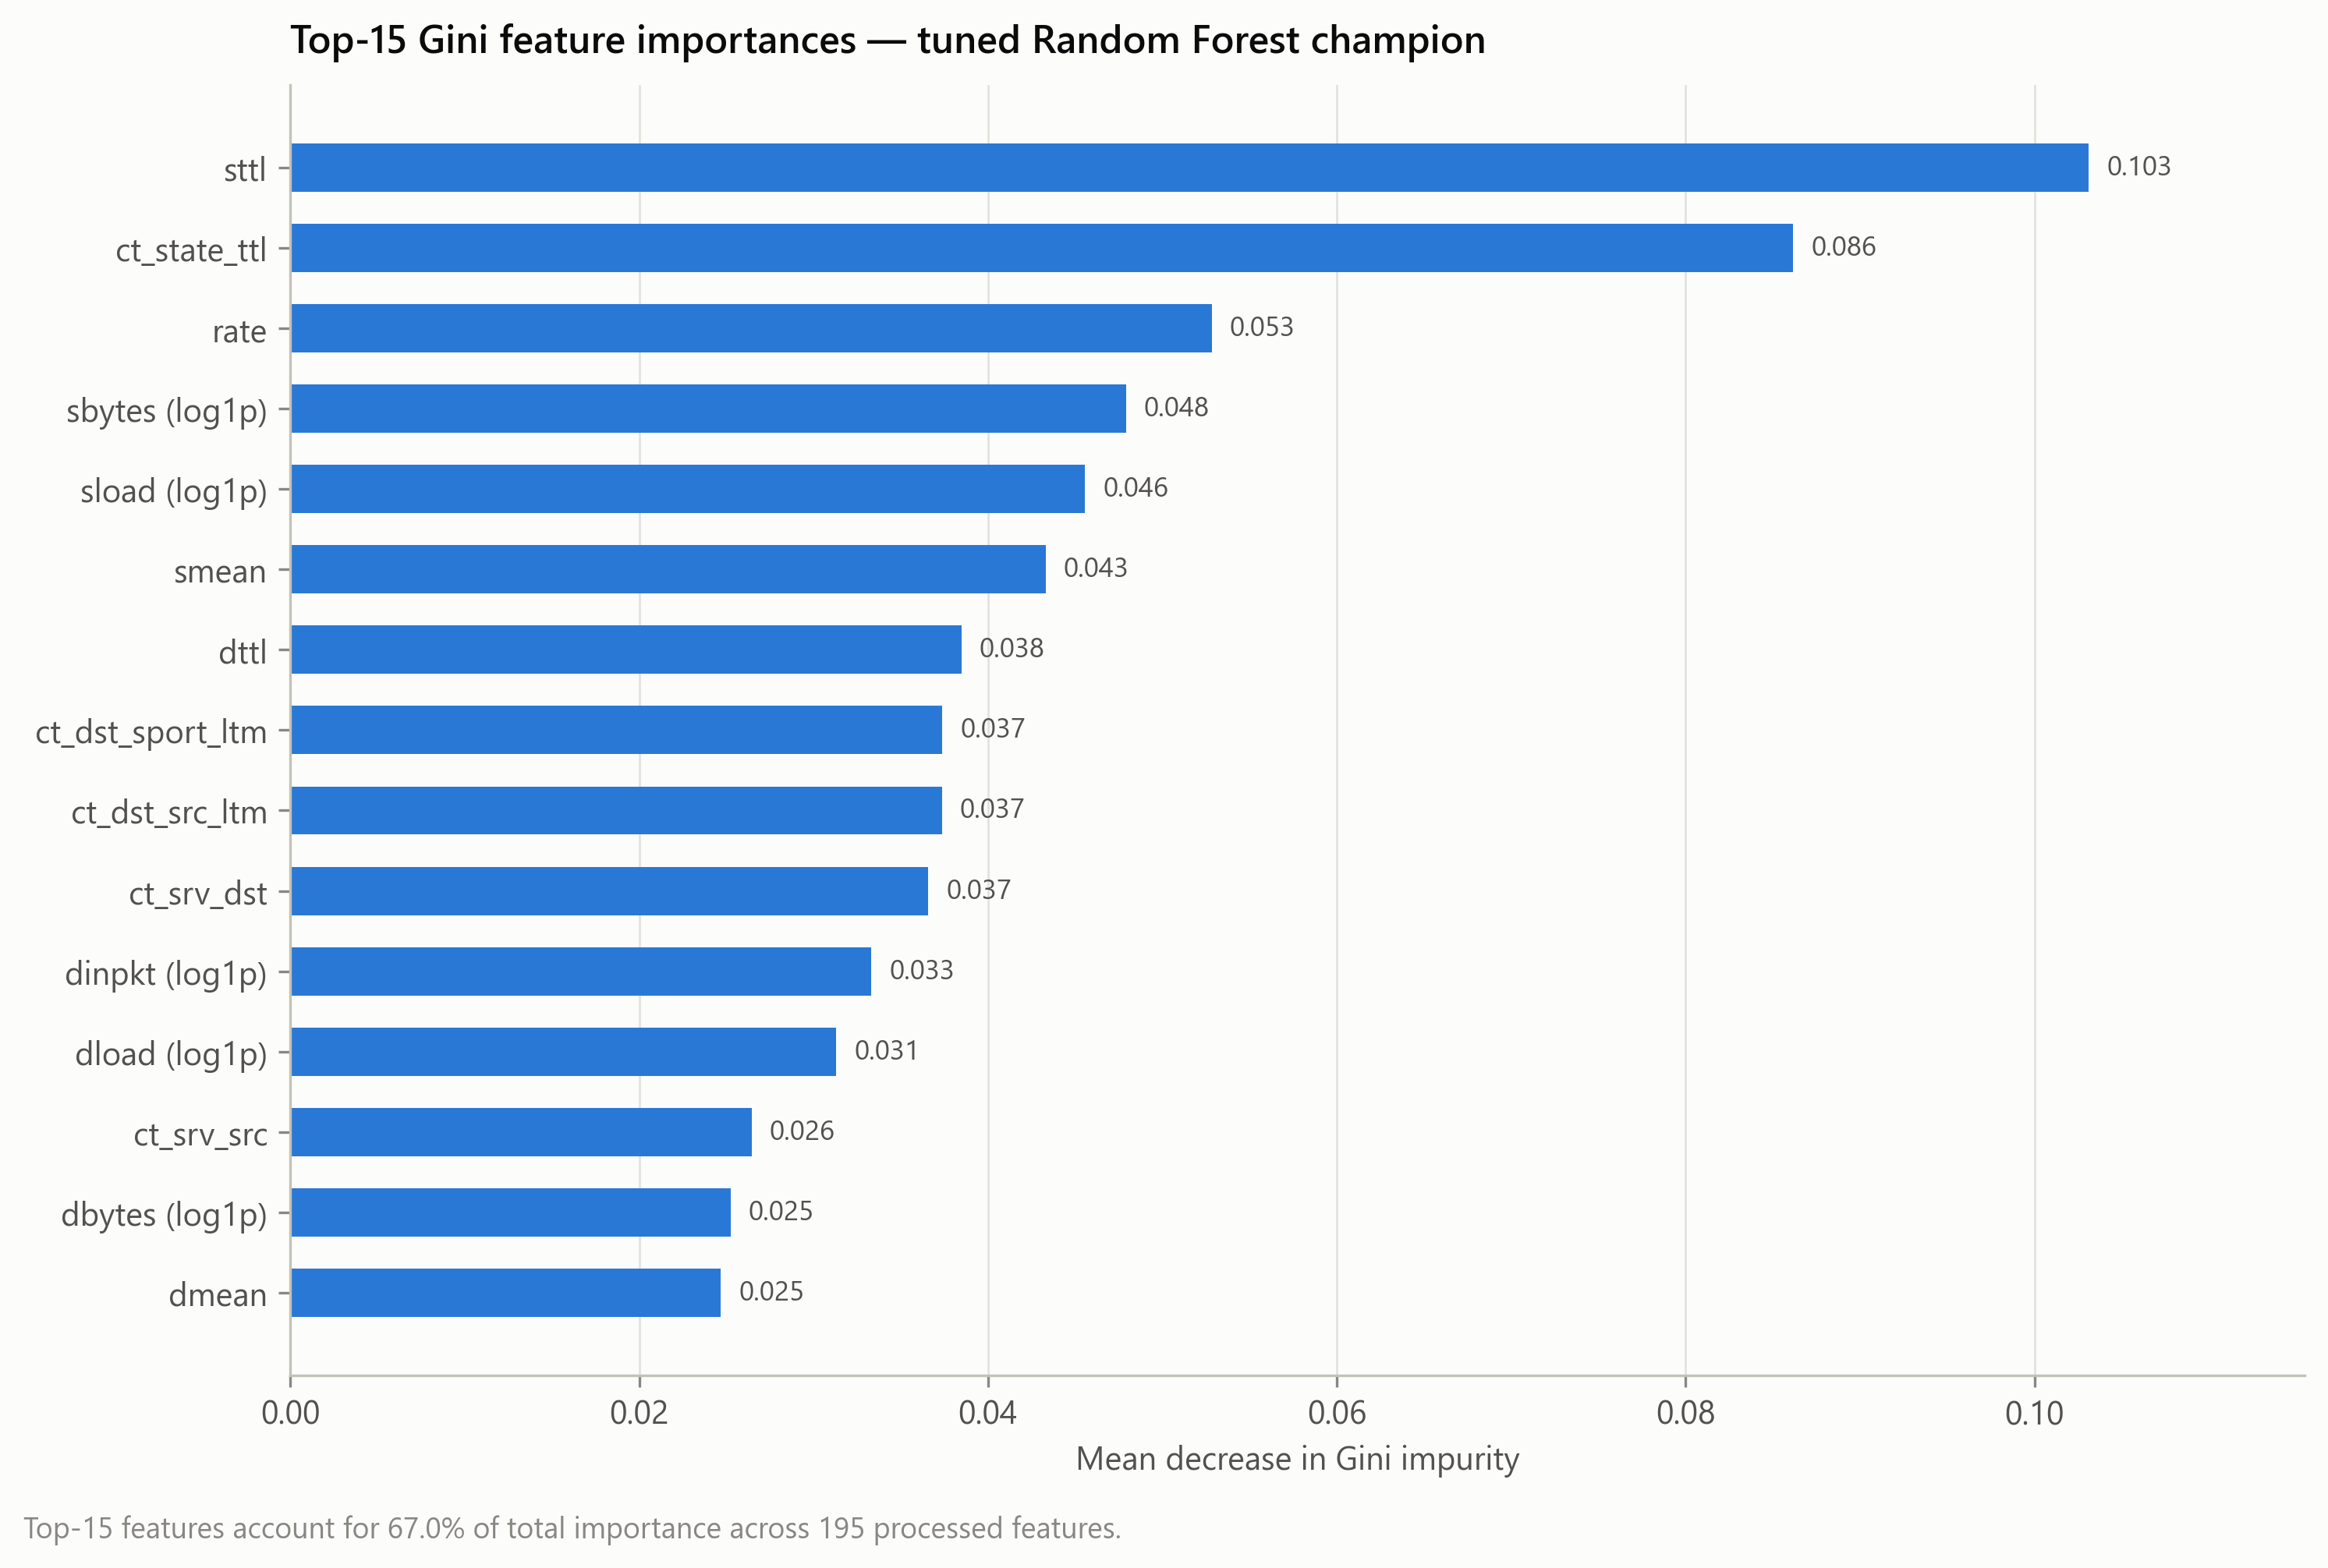

,gini_importance
sttl,0.1031
ct_state_ttl,0.0862
rate,0.0528
sbytes (log1p),0.0479
sload (log1p),0.0456
smean,0.0433
dttl,0.0385
ct_dst_sport_ltm,0.0374
ct_dst_src_ltm,0.0374
ct_srv_dst,0.0366


In [15]:
imp = pd.Series(rf.feature_importances_, index=d["feature_names"]).sort_values(ascending=False)
display(Image(filename=champion.fig_importance(imp), width=900))
imp.head(15).rename(index=champion.pretty).to_frame("gini_importance")

**Reading the model like a SOC analyst.** Time-to-live features (`sttl`, `ct_state_ttl`, `dttl`) dominate:
attack tooling in the testbed emits packets with characteristic initial TTLs and TTL/state combinations that benign
hosts rarely produce — the same fingerprint used to spot OS/tool artefacts in threat hunting. Volume and rate
features (`sbytes`, `smean`, `dbytes`, `sload`) capture payload anomalies — oversized requests typical of
buffer-overflow exploits and tiny, uniform probes typical of scans and fuzzing. Connection-count features
(`ct_srv_dst`, `ct_dst_src_ltm`, `ct_dst_sport_ltm`) measure fan-out to services and ports over the last 100
connections — the behavioural signature of port scanning and reconnaissance.

## 12. Real-Time Threat Detection Benchmark & Streaming SIEM Simulation

,flows,calls,total_s,us_per_flow_mean,us_per_flow_p50,us_per_flow_p95,flows_per_s
batch_size,,,,,,,
1,1000,1000,8.4442,"8,444.1685","7,614.9000","13,304.8600",118.4249
10,2000,200,2.2992,"1,149.5944",832.9800,"2,453.0300",869.8720
100,10000,100,1.5382,153.8188,122.3080,290.8762,"6,501.1572"
1000,10000,10,0.4397,43.9734,43.3557,55.3907,"22,741.0000"
10000,10000,1,0.3097,30.9653,30.9653,30.9653,"32,294.2653"


all cores, one 10,000-flow batch: 7.85 us/flow = 127,425 flows/s


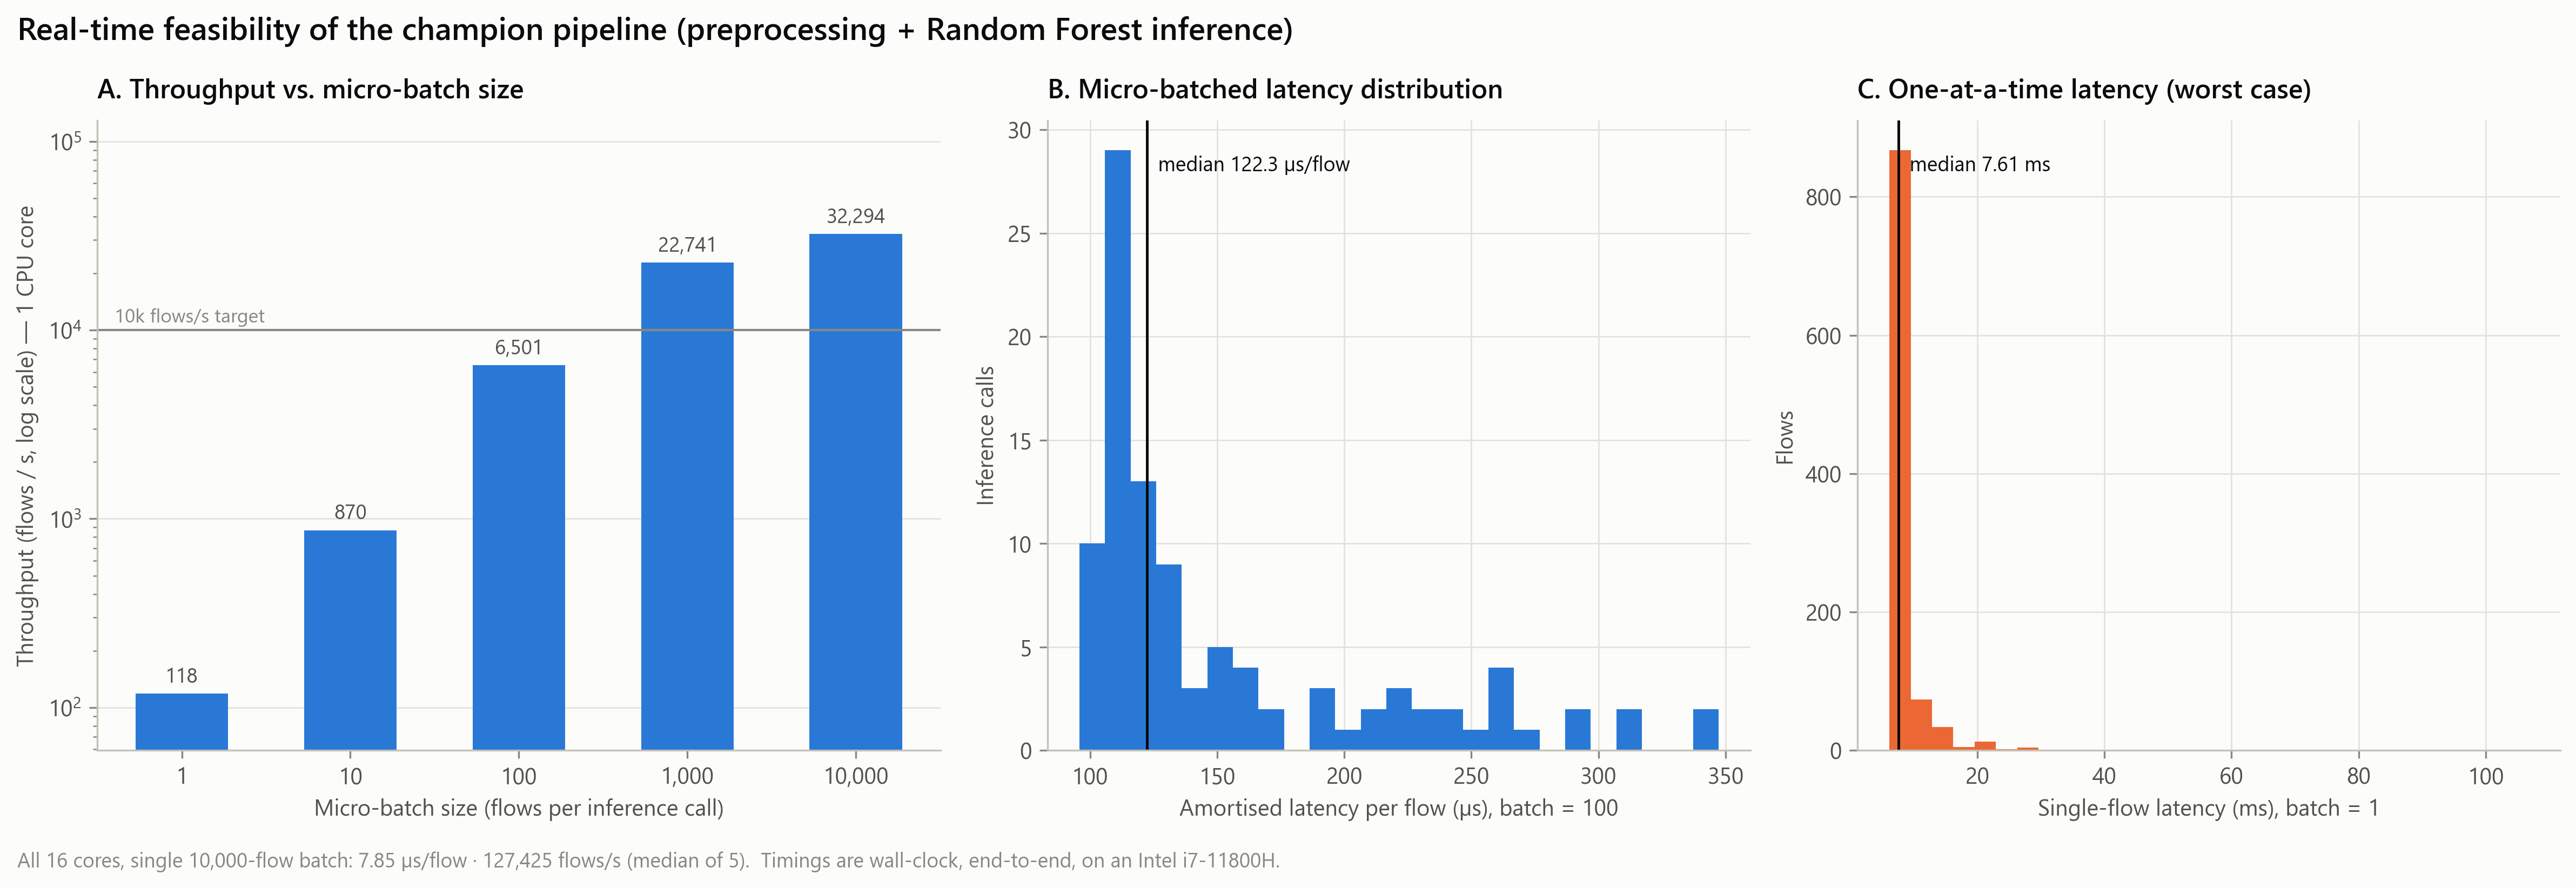

In [16]:
X_tr_raw, X_te_raw, cat_tr_raw, cat_te_raw = d["X_tr"], d["X_te"], d["cat_tr"], d["cat_te"]
tab, per_call, all_cores = realtime.benchmark(d["pre"], rf, X_te_raw.iloc[:realtime.N_BENCH])
display(tab.set_index("batch_size"))
print(f"all cores, one 10,000-flow batch: {all_cores['us_per_flow']:.2f} us/flow = {all_cores['flows_per_s']:,.0f} flows/s")
display(Image(filename=realtime.fig_latency(tab, per_call, all_cores), width=1000))

In [17]:
fam, fam_rep = realtime.train_family_classifier(d["pre"], X_tr_raw, cat_tr_raw, X_te_raw, cat_te_raw)
print("stage-2 family classifier:", {k: fam_rep[k] for k in ("accuracy", "macro_f1")})
lines = realtime.siem_stream(d["pre"], rf, fam, tau, X_te_raw, cat_te_raw)
print("\n".join(lines))

stage-2 family classifier: {'accuracy': 0.7531, 'macro_f1': 0.5676}


[2026-09-11 14:52:40.471] [ALERT] [HIGH] Malicious Flow #43134 Detected!  (wb-mon/-/INT)
  ├─ Attack Category : DoS   (stage-2 guess: match; ground truth: DoS)
  ├─ Detection       : TP
  ├─ Confidence Score: 100.00%   (τ* = 0.50)
  ├─ Latency         : 10,550.50 microseconds
  └─ Action Taken    : TCP RST Packet Dispatched | Flow Blocked
[2026-09-11 14:52:40.545] [ALERT] [HIGH] Malicious Flow #10923 Detected!  (narp/-/INT)
  ├─ Attack Category : Analysis   (stage-2 guess: MISMATCH; ground truth: Backdoor)
  ├─ Detection       : TP
  ├─ Confidence Score: 100.00%   (τ* = 0.50)
  ├─ Latency         : 10,804.00 microseconds
  └─ Action Taken    : TCP RST Packet Dispatched | Flow Blocked
[2026-09-11 14:52:40.623] [ALERT] [CRITICAL] Malicious Flow #50231 Detected!  (tcp/http/FIN)
  ├─ Attack Category : Exploits   (stage-2 guess: match; ground truth: Exploits)
  ├─ Detection       : TP
  ├─ Confidence Score: 99.99%   (τ* = 0.50)
  ├─ Latency         : 25,762.90 microseconds
  └─ Action Taken

**Line-rate feasibility.** A 1 Gbps link at an average of ~1 KB per flow record produces on the order of
10⁴–10⁵ flows/s; flow exporters (NetFlow/IPFIX/Zeek) deliver records in batches, which is exactly the regime where the
pipeline runs at tens of microseconds per flow. One-flow-at-a-time scoring is far slower (milliseconds, dominated by
per-call Python overhead across all trees) — so production deployment should micro-batch, or compile the forest
(e.g. Treelite/ONNX) for the inline path.

## 13. Executive Recommendations for the CISO

1. **Deploy as an *augmenting* detection layer, not a replacement.** The model detects 94.6% of
   attacks at a 5.1% false-alarm rate; pair it with the existing signature NIDS so each covers the
   other's blind spots.
2. **Operate the threshold as policy.** τ* = 0.50 balances recall against a 5 % false-alarm
   budget; lowering τ during elevated threat levels buys recall at a measurable analyst cost (Section 8 curve).
3. **Micro-batch the inline path.** At 6.4 µs/flow batched (157,418 flows/s)
   the model sustains multi-gigabit flow export; avoid per-flow synchronous scoring.
4. **Close the Fuzzers gap.** Fuzzers alone drive the large majority of false negatives (Section 10); add
   payload/DPI features and service-crash telemetry for Fuzzers and Analysis.
5. **Continuous learning & drift monitoring.** Retrain on fresh, labelled SOC triage outcomes; monitor feature
   drift (new protocols map to all-zero one-hot vectors and silently weaken detection).

In [18]:
print(f"Notebook executed end-to-end in {time.perf_counter() - T_START:.1f} s")

Notebook executed end-to-end in 73.1 s
